# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Instalación definitiva y limpieza de conflictos
# %pip install -q \
#     "tensorflow[and-cuda]==2.16.1" \
#     tf-keras==2.16.0 \
#     keras-cv==0.9.0 \
#     keras-cv-attention-models \
#     pandas matplotlib scikit-learn ipywidgets seaborn \
#     lime shap opencv-python \
#     python-dotenv kaggle \
#     optuna optuna-dashboard optuna-integration \
#     pydot \
#     weave nbformat


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

# Hay que instalar manualmente graphviz
# sudo apt install graphviz

# Después tendrás que reiniciar el kernel

In [2]:
# %pip install -q --upgrade wandb

In [3]:
# Cargamos las variables de entorno del archivo .env
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

True

## 2: Configuración de la GPU y librerías

In [4]:
import os

# Usar únicamente la GPU física 1
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import gc

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Fuerza de cómputo actual:", mixed_precision.global_policy())

# Comprobación de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")


# Limpiamos memoria CPU y GPU
tf.keras.backend.clear_session()
gc.collect()

2026-08-29 10:49:52.786272: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-29 10:49:53.574868: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  Tesla P100-PCIE-16GB, compute capability 6.0
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Fuerza de cómputo actual: <Policy "mixed_float16">
🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


0

## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [5]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATASET_PATH="${DATASET_PATH:-$PROJECT_ROOT/datasets}"
DATA_DIR="$DATASET_PATH/ham10000"
COMPRESSED_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"

# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$COMPRESSED_FILE" ]; then
    echo "📦 Escenario B: Archivo de imágenes encontrado pero no descomprimido. Extrayendo ahora con zipfile..."
    python3 -m zipfile -e "$COMPRESSED_FILE" "$DATA_DIR" && rm "$COMPRESSED_FILE"
    echo "✅ Descompresión terminada y archivo eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$COMPRESSED_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo con zipfile..."
    python3 -m zipfile -e "$COMPRESSED_FILE" "$DATA_DIR" && rm "$COMPRESSED_FILE"
fi

# 4. Lógica para los METADATOS
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual metido dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        echo "📦 Extrayendo metadatos comprimidos con zipfile..."
        python3 -m zipfile -e "$DATA_DIR/HAM10000_metadata.csv.zip" "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en ./datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en ./datasets/ham10000/HAM10000_metadata.csv.
🚀 Proceso completo. Imágenes y metadatos preparados en ./datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [6]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [8]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit



# 1. Cargar metadatos
df = pd.read_csv(META_PATH)
df.set_index('image_id', inplace=True) # Facilita la búsqueda por ID

# 2. Mapeo de rutas de archivos (SIN PROCESAR METADATOS AÚN)
all_image_paths = []
all_labels = []
all_img_ids = []

class_names = sorted(os.listdir(DATA_PATH))  
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(folder_path): continue
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_img_ids.append(img_id)

# Creamos el dataframe base combinando rutas con la edad y categorías CRUDA
data_df = pd.DataFrame({
    'path': all_image_paths,
    'label': all_labels,
    'image_id': all_img_ids
})
# Hacemos merge de los metadatos crudos
data_df = data_df.merge(df[['lesion_id', 'age', 'sex', 'localization']], left_on='image_id', right_index=True)

# ==========================================
# 3. DIVISIÓN DEL DATAFRAME (ANTES DEL SCALER)
# ==========================================

# 1. Separar Test (15%) asegurando que las fotos de la misma lesión no se separen
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(data_df, data_df['label'], groups=data_df['lesion_id']))

train_val_df = data_df.iloc[train_val_idx].copy()
test_df = data_df.iloc[test_idx].copy()

# 2. Separar Val (15% del total -> ~17.6% del remanente) agrupando de nuevo
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx, val_idx = next(gss_val.split(train_val_df, train_val_df['label'], groups=train_val_df['lesion_id']))

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print(f"✅ Split Seguro. Pacientes únicos (lesiones) en Train: {train_df['lesion_id'].nunique()}")
print(f"✅ Pacientes únicos (lesiones) en Test: {test_df['lesion_id'].nunique()}")

# Comprobación de seguridad matemática (Si esto da más de 0, algo ha fallado)
fugas = set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))
assert len(fugas) == 0, f"¡ERROR DE DATA LEAKAGE! Hay {len(fugas)} pacientes en Train y Test a la vez."

# ==========================================
# 4. PREPROCESAMIENTO
# ==========================================

# A. Rellenar nulos (Solo usando la media de Train)
mean_age = train_df['age'].mean()
train_df['age'] = train_df['age'].fillna(mean_age)
val_df['age'] = val_df['age'].fillna(mean_age)
test_df['age'] = test_df['age'].fillna(mean_age)

# B. Escalado de la edad (fit solo en Train)
scaler = StandardScaler()
train_age_scaled = scaler.fit_transform(train_df[['age']])
val_age_scaled = scaler.transform(val_df[['age']])
test_age_scaled = scaler.transform(test_df[['age']])

# C. Encoding (fit solo en Train, handle_unknown ignora categorías nuevas en Test)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_cat = encoder.fit_transform(train_df[['sex', 'localization']])
val_cat = encoder.transform(val_df[['sex', 'localization']])
test_cat = encoder.transform(test_df[['sex', 'localization']])

# D. Agrupar los features escalados en una lista por fila para facilitar la extracción
train_df['meta'] = list(np.hstack([train_age_scaled, train_cat]).astype(np.float32))
val_df['meta'] = list(np.hstack([val_age_scaled, val_cat]).astype(np.float32))
test_df['meta'] = list(np.hstack([test_age_scaled, test_cat]).astype(np.float32))

# ==========================================
# 5. EXTRACCIÓN DE VARIABLES FINALES (¡SIN BALANCEAR!)
# ==========================================

# --- Extraer variables usando directamente el set original desbalanceado ---
train_paths = train_df['path'].values
train_meta = np.stack(train_df['meta'].values)
train_labels = train_df['label'].values 

val_paths = val_df['path'].values
val_meta = np.stack(val_df['meta'].values)
val_labels = val_df['label'].values

test_paths = test_df['path'].values
test_meta = np.stack(test_df['meta'].values)
test_labels = test_df['label'].values

print(f"📊 Reparto final: Train ({len(train_paths)}), Val ({len(val_paths)}), Test ({len(test_paths)})")

def get_class_counts(labels, n_classes=7):
    return np.bincount(labels, minlength=n_classes)

def make_class_balanced_augment_ds(train_paths, train_meta, train_labels, batch_size, target_count=None):
    n_classes = int(np.max(train_labels)) + 1
    class_counts = get_class_counts(train_labels, n_classes=n_classes)

    if target_count is None:
        target_count = int(class_counts.max())

    datasets = []

    for class_idx in range(n_classes):
        class_mask = train_labels == class_idx
        class_paths = train_paths[class_mask]
        class_meta = train_meta[class_mask]
        class_labels = train_labels[class_mask]

        if len(class_paths) == 0:
            continue

        class_ds = tf.data.Dataset.from_tensor_slices((class_paths, class_meta, class_labels))
        class_ds = class_ds.shuffle(len(class_paths), reshuffle_each_iteration=True)
        class_ds = class_ds.repeat()

        repeat_factor = int(np.ceil(target_count / len(class_paths)))
        class_ds = class_ds.take(repeat_factor * len(class_paths))

        datasets.append(class_ds)

    balanced_ds = datasets[0]
    for ds in datasets[1:]:
        balanced_ds = balanced_ds.concatenate(ds)

    balanced_ds = balanced_ds.shuffle(target_count * n_classes, reshuffle_each_iteration=True)
    return balanced_ds, class_counts, target_count

def augment_by_class(image, class_idx, class_counts, target_count, base_zoom=0.10, base_rotation=0.50):
    class_idx = int(class_idx)

    if class_counts[class_idx] == 0:
        return image

    ratio = target_count / float(class_counts[class_idx])

    if ratio <= 1.0:
        return image

    extra_zoom = min(base_zoom * ratio, 0.30)
    extra_rotation = min(base_rotation * ratio, 1.0)

    if tf.random.uniform([]) < extra_rotation:
        image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))

    if extra_zoom > 0:
        scale = tf.random.uniform([], 1.0 - extra_zoom, 1.0)
        new_size = tf.cast(tf.cast(224, tf.float32) * scale, tf.int32)
        new_size = tf.maximum(new_size, 128)
        image = tf.image.random_crop(image, size=[new_size, new_size, 3])
        image = tf.image.resize(image, [224, 224])

    return image

def process_balanced_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return (img, metadata), tf.one_hot(label, depth=7)

# Código duplicado, pero con impact más abajo, tener cuidado

 # ==========================================
 # 6. FUNCIÓN DE PROCESAMIENTO Y TF.DATA
 # ==========================================
def process_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return (img, metadata), tf.one_hot(label, depth=7)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_meta, test_labels))
test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.")

✅ Split Seguro. Pacientes únicos (lesiones) en Train: 5231
✅ Pacientes únicos (lesiones) en Test: 1121
📊 Reparto final: Train (6963), Val (1525), Test (1527)
✅ Datasets creados con éxito, variables sincronizadas, TODOS los datos incluidos y SIN data leakage.


2026-08-29 10:49:55.953178: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:238] Using CUDA malloc Async allocator for GPU: 0
2026-08-29 10:49:55.953550: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15508 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:af:00.0, compute capability: 6.0


📊 Distribución exacta de muestras por partición:


,Train (70%),Validación (15%),Test (15%)
Actinic Keratoses,222,57,48
Basal Cell Carcinoma,349,99,66
Benign Keratosis,770,157,172
Dermatofibroma,92,13,10
Melanocytic Nevi,4665,1024,1016
Melanoma,771,156,186
Vascular Lesions,94,19,29


------------------------------------------------------------
Totales -> Train: 6963 | Val: 1525 | Test: 1527


<Figure size 1200x600 with 0 Axes>

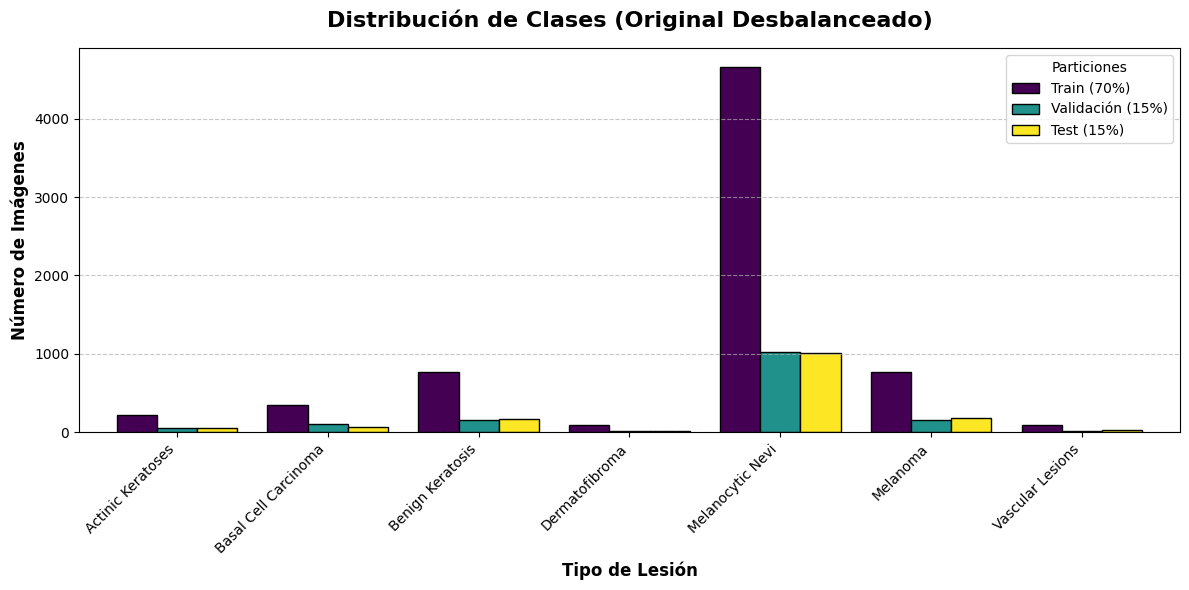

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Contar las ocurrencias de cada clase en cada partición
train_counts = pd.Series(train_labels).value_counts().sort_index()
val_counts = pd.Series(val_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

# 2. Crear un DataFrame resumen para verlo bonito
dist_df = pd.DataFrame({
    'Train (70%)': train_counts,
    'Validación (15%)': val_counts,
    'Test (15%)': test_counts
})

# Reemplazamos el índice numérico (0 al 6) por los nombres reales de las carpetas
dist_df.index = class_names

print("📊 Distribución exacta de muestras por partición:")
display(dist_df) # 'display' lo formatea como una tabla bonita en Jupyter

print("-" * 60)
print(f"Totales -> Train: {len(train_labels)} | Val: {len(val_labels)} | Test: {len(test_labels)}")

# 3. Visualización Gráfica
plt.figure(figsize=(12, 6))
dist_df.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis', edgecolor='black')

plt.title('Distribución de Clases (Original Desbalanceado)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tipo de Lesión', fontsize=12, fontweight='bold')
plt.ylabel('Número de Imágenes', fontsize=12, fontweight='bold')

# Rotar los nombres para que se lean bien
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Particiones')

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 10015 entries, ISIC_0027419 to ISIC_0032258
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   dx            10015 non-null  object 
 2   dx_type       10015 non-null  object 
 3   age           9958 non-null   float64
 4   sex           10015 non-null  object 
 5   localization  10015 non-null  object 
dtypes: float64(1), object(5)
memory usage: 805.7+ KB
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
25%      40.000000
50%      50.000000
75%      65.000000
max      85.000000


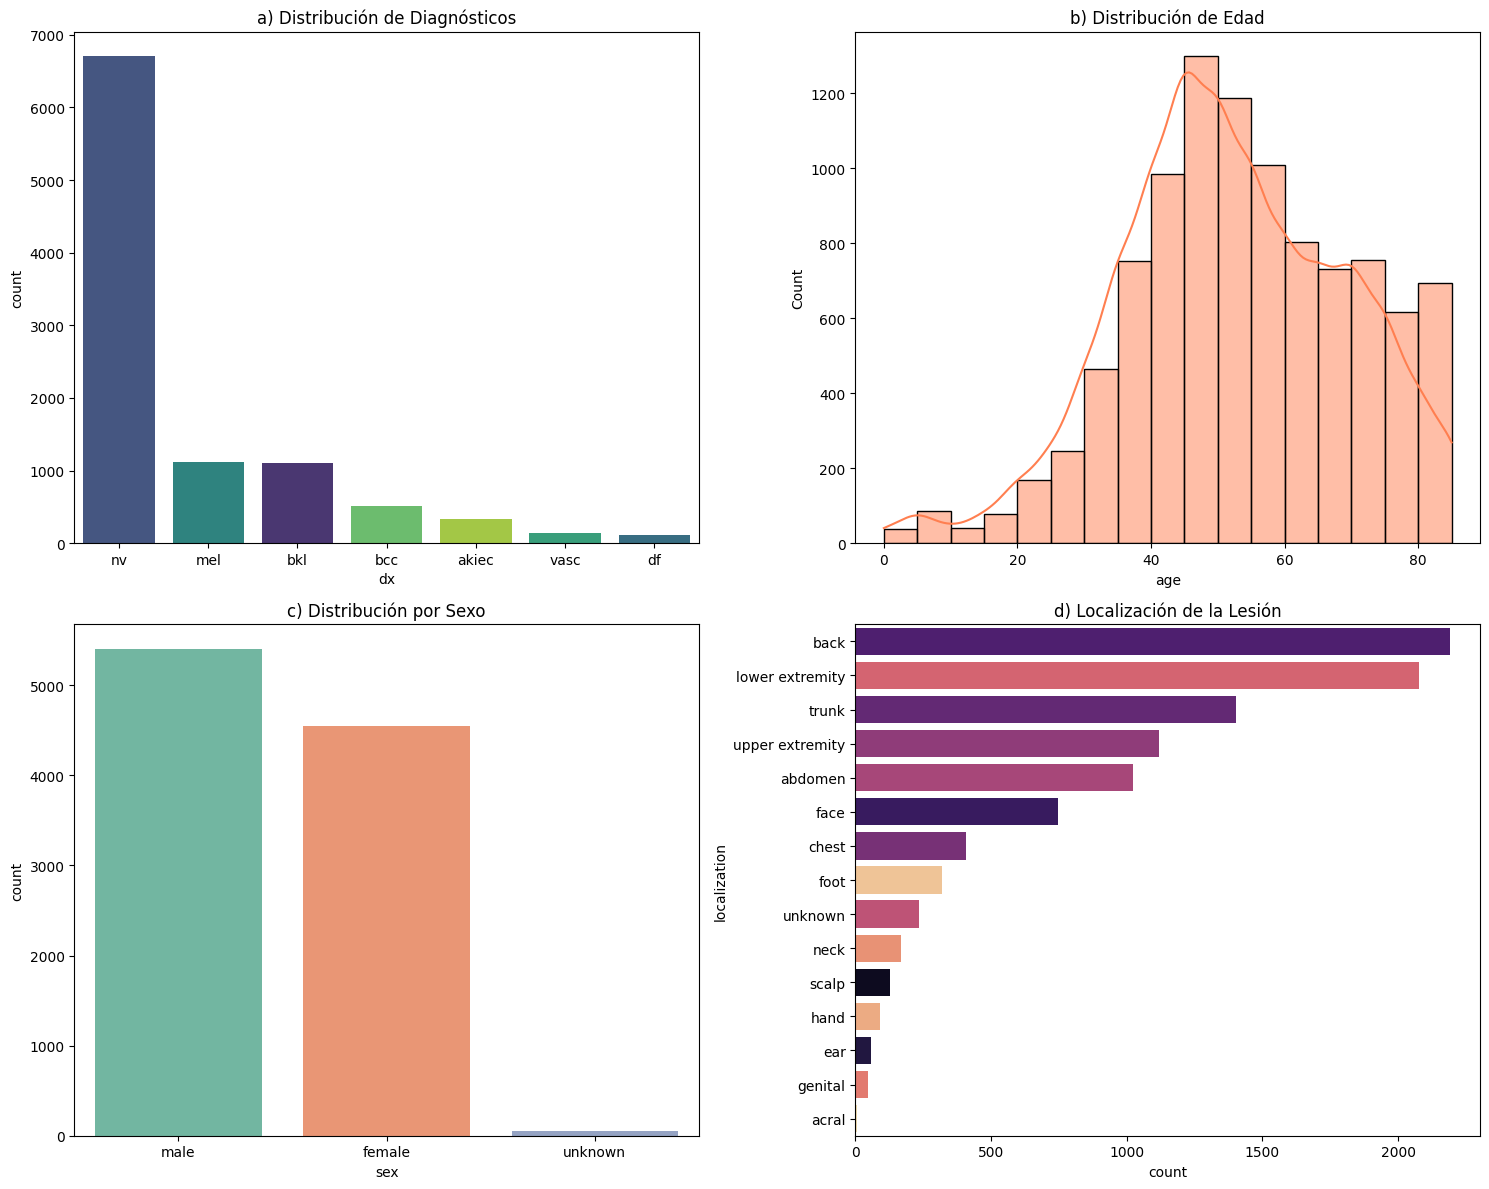

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
print(df.describe())

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Diagnóstico (Ordenado para ver el desbalance)
# Solución: Añadimos hue='dx' y legend=False
sns.countplot(data=df, x='dx', hue='dx', order=df['dx'].value_counts().index, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('a) Distribución de Diagnósticos')

# Gráfico 2: Edad
# Este se queda igual, ya que histplot usa un color único ('color') y no una paleta ('palette')
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('b) Distribución de Edad')

# Gráfico 3: Sexo
# Solución: Añadimos hue='sex' y legend=False
sns.countplot(data=df, x='sex', hue='sex', order=df['sex'].value_counts().index, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('c) Distribución por Sexo')

# Gráfico 4: Localización
# Solución: Como aquí las barras son horizontales (y='localization'), el hue debe ser igual a 'localization'
sns.countplot(data=df, y='localization', hue='localization', order=df['localization'].value_counts().index, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('d) Localización de la Lesión')

plt.tight_layout()
plt.show()

In [11]:
print("--- 1. RECUENTO DE VALORES ÚNICOS ---")
# nunique() nos dice cuántas opciones distintas hay por cada columna
print(df.nunique())

print("\n--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---")
# Para las variables de texto, a veces queremos ver exactamente cuáles son esas opciones
columnas_interes = ['dx', 'dx_type', 'sex']
for col in columnas_interes:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

print("\n--- 3. DUPLICADOS ---")
# Primero, buscamos si hay filas donde ABSOLUTAMENTE TODO sea idéntico
filas_clonadas = df.duplicated().sum()
print(f"Filas 100% duplicadas (errores de registro): {filas_clonadas}")

# Y ahora, el detalle vital del HAM10000:
# ¿Hay alguna foto repetida? ¿Y cuántas pecas tienen múltiples fotos?
# FIXME: ARREGLAR ESTO
# fotos_duplicadas = df['image_id'].duplicated().sum()
lesiones_duplicadas = df['lesion_id'].duplicated().sum()

# print(f"Imágenes con el mismo ID (fotos repetidas): {fotos_duplicadas}")
print(f"Lesiones con el mismo ID (misma lesión, varias fotos): {lesiones_duplicadas}")

--- 1. RECUENTO DE VALORES ÚNICOS ---
lesion_id       7470
dx                 7
dx_type            4
age               18
sex                3
localization      15
dtype: int64

--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---

Valores únicos en 'dx':
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Valores únicos en 'dx_type':
['histo' 'consensus' 'confocal' 'follow_up']

Valores únicos en 'sex':
['male' 'female' 'unknown']

--- 3. DUPLICADOS ---
Filas 100% duplicadas (errores de registro): 2543
Lesiones con el mismo ID (misma lesión, varias fotos): 2545


Creamos la función que leerá tanto la imagen como los metadatos

In [12]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


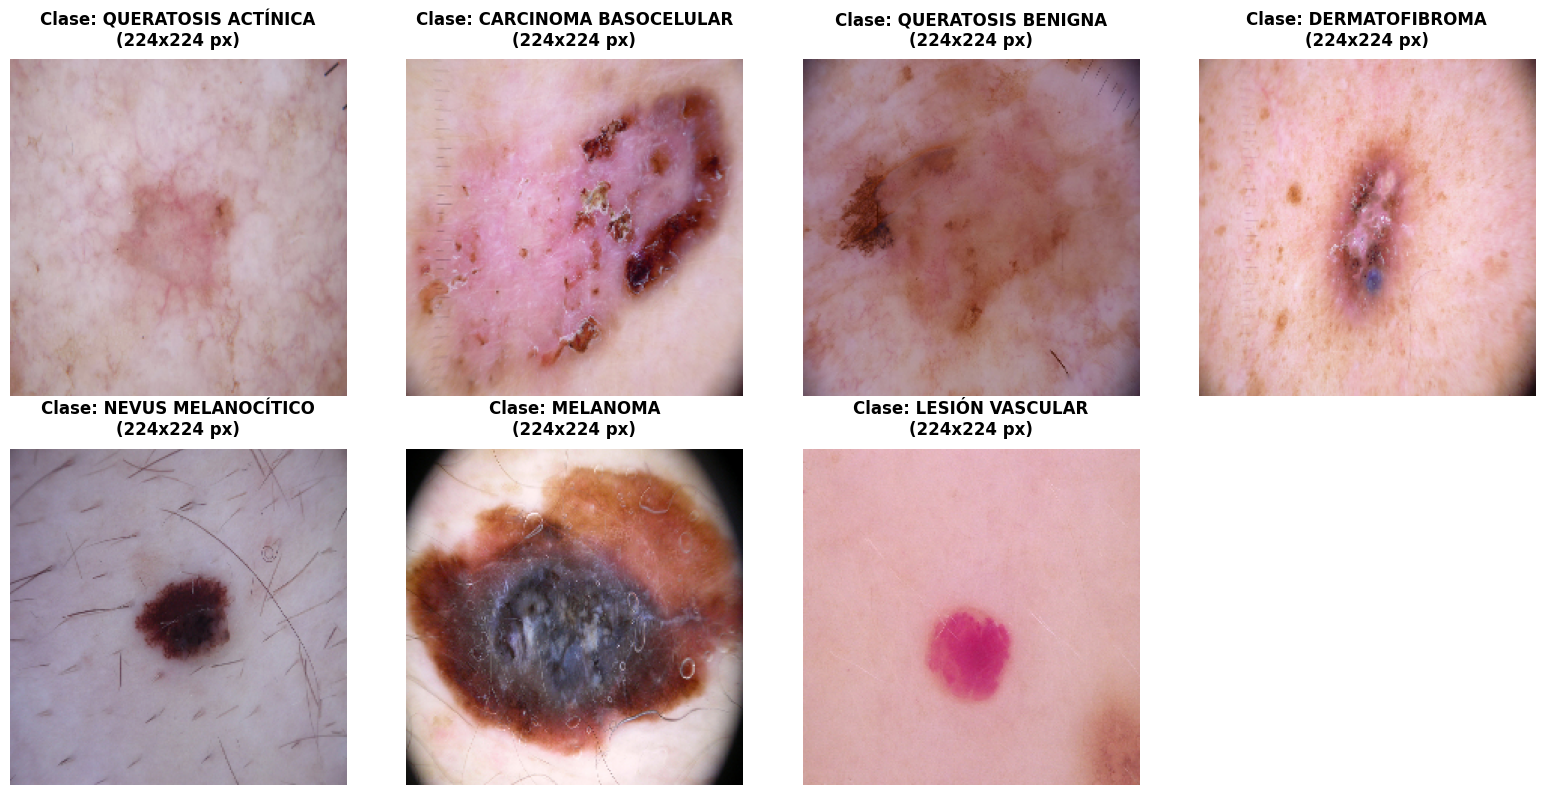

In [13]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

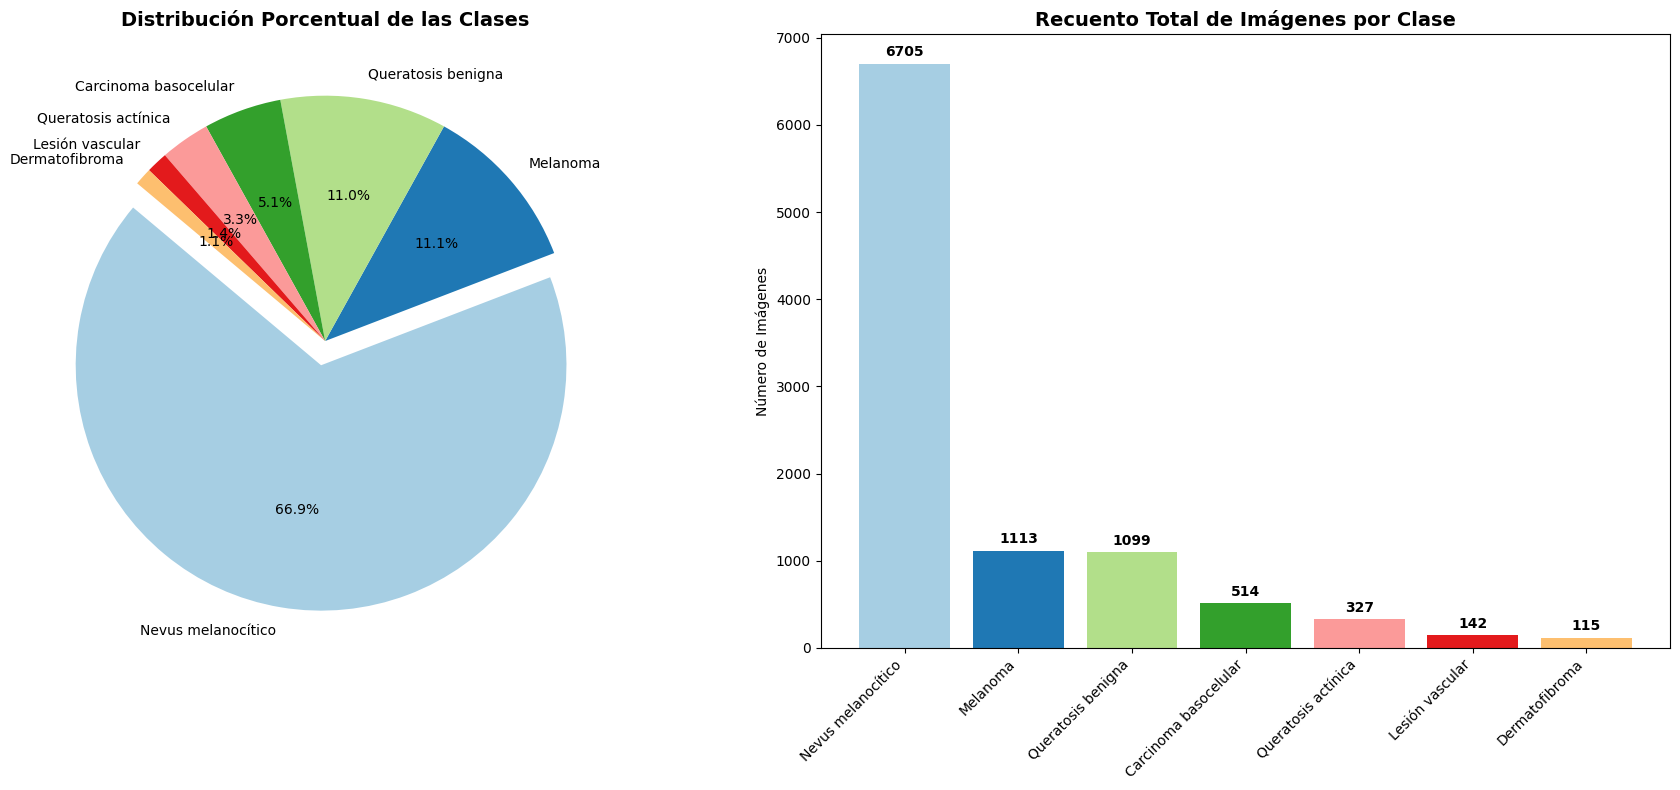


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [14]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

## 5: Búsqueda de hiperparámetros

Primero configuramos Optuna como optimizador:

In [15]:
import optuna
storage_name = "sqlite:///optuna_tfm.db"
print(f"✅ Optuna DB lista en {storage_name}")

✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [16]:
import numpy as np
from keras_cv_attention_models import coatnet
from optuna_integration import TFKerasPruningCallback
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import keras_cv_attention_models
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
from sklearn.metrics import precision_score, recall_score
import gc
import datetime
import time
import optuna
import tensorflow as tf
import traceback

MODEL_NAME = "EfficientNetB0"
STUDY_NAME = f"Base study FIXED {MODEL_NAME} {BATCH_SIZE}"
print(f"🚀 Lanzando estudio de Optuna: {STUDY_NAME}")

# -------------------------------------------------
# 1) ALPHA WEIGHTS
# -------------------------------------------------
pesos_balanceados = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

alpha_weights = np.asarray(pesos_balanceados, dtype=np.float32)

# Suavizado opcional: mantiene pesos, pero evita extremos demasiado agresivos
tau = 0.7
alpha_weights = alpha_weights ** tau
alpha_weights = alpha_weights / alpha_weights.mean()

print("Alpha weights finales:")
for i, peso in enumerate(alpha_weights):
    print(f"Clase {i}: {peso:.4f}")


# -------------------------------------------------
# 2) AUGMENTATION POR CLASE
# -------------------------------------------------
def augment_by_class_tf(
    image,
    class_idx,
    class_counts_tf,
    target_count_tf,
    base_zoom=0.08,
    base_rotation=0.35,
    minority_boost=0.8,
    max_zoom=0.35,
):
    class_idx = tf.cast(class_idx, tf.int32)
    class_count = tf.maximum(tf.gather(class_counts_tf, class_idx), 1)
    imbalance = target_count_tf / tf.cast(class_count, tf.float32)

    # > 1.0 en minoritarias, ~1.0 en mayoritarias
    strength = tf.clip_by_value(
        1.0 + minority_boost * (imbalance - 1.0),
        1.0,
        2.5
    )

    extra_zoom = tf.minimum(base_zoom * strength, max_zoom)
    extra_rotation = tf.minimum(base_rotation * strength, 1.0)

    image = tf.cond(
        tf.random.uniform([]) < extra_rotation,
        lambda: tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32)),
        lambda: image
    )

    def zoom_path(img):
        scale = tf.random.uniform([], 1.0 - extra_zoom, 1.0)
        new_size = tf.cast(IMG_SIZE[0] * scale, tf.int32)
        new_size = tf.maximum(new_size, 128)
        cropped = tf.image.random_crop(img, size=[new_size, new_size, 3])
        return tf.image.resize(cropped, IMG_SIZE)

    image = tf.cond(extra_zoom > 0, lambda: zoom_path(image), lambda: image)
    return image


# -------------------------------------------------
# 3) CONFIG GLOBAL
# -------------------------------------------------
BASE_CONFIG = {
    "model_architecture": MODEL_NAME,
    "study_name": STUDY_NAME,
    "dataset": "HAM10000",
    "keras_mode": "Legacy (TF_USE_LEGACY_KERAS=1)",
    "precision": "float16 (mixed precision con softmax en float32)",
    "base_model_trainable": "True",
    "img_size": 224,
    "batch_size": BATCH_SIZE,
    "split_method": "GroupShuffleSplit",
    "split_group": "lesion_id",
    "test_size": 0.15,
    "val_size": 0.176,
    "random_state": 42,
    "tabular_imputation": "Media (Age)",
    "tabular_scaling": "StandardScaler",
    "tabular_encoding": "OneHotEncoder (handle_unknown='ignore')",
    "image_normalization": "Division por 255.0",
    "class_balancing_method": "sklearn.utils.class_weight (balanced)",
    "class_weight_multipliers": "Optuna: mel_multiplier & bcc_multiplier (recomputado por trial)",
    "loss_function": "CategoricalFocalCrossentropy",
    "focal_loss_gamma": "Optuna variable (focal_gamma)",
    "alpha_weights_normalization": "Reescalado por tau (Optuna) y normalización por la media",
    "augmentation_strategy": "Random Crop & Resize (TF puro) + Rotación 90º",
    "augmentation_scope": "Todas las clases, con mayor intensidad en minoritarias",
    "augmentation_implementation": "tf.data pipeline .map() (per-trial params)",
    "augmentation_location": "Dentro del trial de Optuna y del entrenamiento final",
    "optuna_search_space": "mel_multiplier,bcc_multiplier,tau,focal_gamma,minority_boost,base_zoom,base_rotation",
    "objective_metric": "composite_score (recall_mel prioritized)"
}

notas = """
Objetivo/Hipótesis:
Test de EfficientNetB0 para usar como comparativa base

Métrica objetivo (composite):
score = 0.50*recall_melanoma + 0.20*precision_melanoma + 0.20*recall_bcc + 0.10*precision_bcc

"""

# -------------------------------------------------
# 4) PARÁMETROS DE AUGMENTATION
# -------------------------------------------------
ZOOM_FACTOR = 0.10
ROTATION_PROB = 0.5


# -------------------------------------------------
# 5) DATASET DE ENTRENAMIENTO CON AUGMENTATION
# -------------------------------------------------
class_counts = get_class_counts(train_labels, n_classes=7)
target_count = int(class_counts.max())

class_counts_tf = tf.constant(class_counts, dtype=tf.int32)
target_count_tf = tf.constant(target_count, dtype=tf.float32)

train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds_aug = train_ds_aug.shuffle(len(train_paths), reshuffle_each_iteration=True)

train_ds_aug = train_ds_aug.map(
    lambda path, meta, label: (
        (
            augment_by_class_tf(
                tf.image.resize(
                    tf.cast(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), tf.float32) / 255.0,
                    IMG_SIZE
                ),
                label,
                class_counts_tf,
                target_count_tf,
                base_zoom=ZOOM_FACTOR,
                base_rotation=ROTATION_PROB,
                minority_boost=0.8,
                max_zoom=0.35,
            ),
            meta
        ),
        tf.one_hot(label, depth=7)
    ),
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)


# -------------------------------------------------
# 6) CALLBACK DE TIEMPOS
# -------------------------------------------------
class WandbTimeCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\n⏰ Inicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.start_time
        self.epoch_times.append(duration)

        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"✅ Fin Época {epoch + 1}: {hora_actual} (Duración: {duration:.2f}s)")

        wandb.log({"epoch_duration_seconds": duration, "epoch": epoch}, commit=False)

    def on_train_end(self, logs=None):
        if self.epoch_times:
            avg_time = sum(self.epoch_times) / len(self.epoch_times)
            wandb.run.summary["avg_epoch_duration_seconds"] = avg_time
            print(f"📊 Resumen del Trial -> Tiempo medio por época: {avg_time:.2f} segundos")


# -------------------------------------------------
# 7) FUNCIÓN OBJETIVO OPTUNA
# -------------------------------------------------
def objective(trial):
    try:
        tf.keras.backend.clear_session()
        gc.collect()

        # ---------- Hiperparámetros buscados ----------
        lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        meta_units = trial.suggest_int("meta_units", 16, 64)
        meta_layers = trial.suggest_int("meta_layers", 1, 3)

        # Multiplicadores para clases cancerígenas (Melanoma, BCC)
        mel_multiplier = trial.suggest_float("mel_multiplier", 1.0, 2.5)
        bcc_multiplier = trial.suggest_float("bcc_multiplier", 1.0, 2.0)

        # Reescalado / focal params
        tau_trial = trial.suggest_float("tau", 0.4, 1.2)
        focal_gamma = trial.suggest_float("focal_gamma", 1.0, 3.0)

        # Augmentation strength (per-trial)
        minority_boost = trial.suggest_float("minority_boost", 0.2, 1.5)
        base_zoom = trial.suggest_float("base_zoom", 0.05, 0.25)
        base_rotation = trial.suggest_float("base_rotation", 0.10, 0.6)

        # ---------- Trial config / W&B ----------
        trial_config = {
            **BASE_CONFIG,
            "hipotesis": "Optuna: composite_score (recall_mel prioritized)",
            "learning_rate": lr,
            "dropout": dropout,
            "meta_units": meta_units,
            "meta_layers": meta_layers,
            "mel_multiplier": mel_multiplier,
            "bcc_multiplier": bcc_multiplier,
            "tau": tau_trial,
            "focal_gamma": focal_gamma,
            "minority_boost": minority_boost,
            "base_zoom": base_zoom,
            "base_rotation": base_rotation,
        }

        wandb.init(
            project="TFM_Melanoma",
            name=f"Trial_{trial.number}",
            group=STUDY_NAME,
            job_type="hyperparameter_optimization",
            tags=["optuna", "composite_score", MODEL_NAME],
            save_code=True,
            config=trial_config,
            notes=notas,
        )

        # ---------- Recalcular alpha weights para este trial ----------
        alpha_trial = alpha_weights.copy()
        # Ajusta índices si tu mapping es distinto (aquí: melanoma=5, bcc=1)
        alpha_trial[5] = alpha_trial[5] * mel_multiplier
        alpha_trial[1] = alpha_trial[1] * bcc_multiplier
        alpha_trial = alpha_trial ** tau_trial
        alpha_trial = alpha_trial / alpha_trial.mean()

        # ---------- Dataset de entrenamiento con augmentation (para este trial) ----------
        class_counts_tf_local = tf.constant(class_counts, dtype=tf.int32)
        target_count_tf_local = tf.constant(int(target_count), dtype=tf.float32)

        def map_fn(path, meta, label):
            # ¡OJO AQUÍ! Quitamos también la división por 255.0 para Optuna
            img = tf.cast(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), tf.float32)
            img = tf.image.resize(img, IMG_SIZE)
            aug = augment_by_class_tf(
                img,
                label,
                class_counts_tf_local,
                target_count_tf_local,
                base_zoom=base_zoom,
                base_rotation=base_rotation,
                minority_boost=minority_boost,
                max_zoom=0.35,
            )
            return (aug, meta), tf.one_hot(label, depth=7)

        train_ds_trial = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
        train_ds_trial = train_ds_trial.shuffle(len(train_paths), reshuffle_each_iteration=True)
        train_ds_trial = train_ds_trial.map(map_fn, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

        # ---------- Construcción del modelo ----------
        from tensorflow.keras import mixed_precision
        from tensorflow.keras.applications import EfficientNetB0

        # 1. APAGAR mixed_precision temporalmente para esquivar el bug
        mixed_precision.set_global_policy('float32')

        # 2. Input en float32 y creación de EfficientNetB0
        input_img = layers.Input(shape=(224, 224, 3), name="image_input", dtype=tf.float32)
        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_tensor=input_img,
            pooling=None,
        )

        # 3. ENCENDER mixed_precision de nuevo
        mixed_precision.set_global_policy('mixed_float16')

        base_model.trainable = True
        
        # 4. Congelación / Descongelación para EfficientNetB0
        for layer in base_model.layers:
            layer.trainable = False
        for layer in base_model.layers:
            if layer.name.startswith("block7") or layer.name.startswith("block6") or "top_conv" in layer.name:
                layer.trainable = True
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization) or "bn" in layer.name.lower():
                layer.trainable = False

        # 5. Extraer características (usamos base_model.output)
        img_features = layers.GlobalAveragePooling2D()(base_model.output)

        # ---------- El resto del modelo sigue IGUAL ----------
        input_meta = layers.Input(shape=(train_meta.shape[1],), name="meta_input")
        x_meta = input_meta
        for _ in range(meta_layers):
            x_meta = layers.Dense(meta_units, activation="relu")(x_meta)
            x_meta = layers.BatchNormalization()(x_meta)

        combined = layers.Concatenate()([img_features, x_meta])
        x = layers.Dense(256, activation="relu")(combined)
        x = layers.Dropout(dropout)(x)
        output = layers.Dense(7, activation="softmax", dtype="float32", name="predictions_float32")(x)

        model = models.Model(inputs=[input_img, input_meta], outputs=output)

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_trial, gamma=focal_gamma),
            metrics=[
                "accuracy",
                tf.keras.metrics.Recall(class_id=5, name="recall_melanoma"),
                tf.keras.metrics.Recall(class_id=1, name="recall_bcc"),
            ],
        )

        # ---------- Callback de pruning basado en la métrica compuesta ----------

        mel_idx = 5
        bcc_idx = 1

        class EvalPruningCallback(tf.keras.callbacks.Callback):
            def on_epoch_end(self, epoch, logs=None):
                # calcular predicciones sobre val_ds
                y_true = []
                y_pred = []
                for (images, metas), labels in val_ds:
                    preds = self.model.predict((images, metas), verbose=0)
                    y_true.extend(np.argmax(labels.numpy(), axis=1))
                    y_pred.extend(np.argmax(preds, axis=1))

                y_true = np.array(y_true)
                y_pred = np.array(y_pred)

                precision_mel = precision_score(y_true, y_pred, labels=[mel_idx], average="macro", zero_division=0)
                recall_mel = recall_score(y_true, y_pred, labels=[mel_idx], average="macro", zero_division=0)
                precision_bcc = precision_score(y_true, y_pred, labels=[bcc_idx], average="macro", zero_division=0)
                recall_bcc = recall_score(y_true, y_pred, labels=[bcc_idx], average="macro", zero_division=0)

                score = 0.50 * recall_mel + 0.20 * precision_mel + 0.20 * recall_bcc + 0.10 * precision_bcc

                # reportar y posible prune
                trial.report(score, step=epoch)
                wandb.log({
                    "recall_mel_epoch": recall_mel,
                    "precision_mel_epoch": precision_mel,
                    "recall_bcc_epoch": recall_bcc,
                    "precision_bcc_epoch": precision_bcc,
                    "composite_score_epoch": score,
                    "epoch": epoch,
                }, commit=False)

                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

        # ---------- Callbacks y entrenamiento ----------
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=0)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
        timestamp_cb = WandbTimeCallback()
        pruning_cb = EvalPruningCallback()

        history = model.fit(
            train_ds_trial,
            validation_data=val_ds,
            epochs=30,
            callbacks=[
                lr_scheduler,
                early_stop,
                timestamp_cb,
                pruning_cb,
                WandbMetricsLogger(),
            ],
            verbose=0,
        )

        # ---------- Evaluación final (val) y retorno del score ----------
        y_true = []
        y_pred = []
        for (images, metas), labels in val_ds:
            preds = model.predict((images, metas), verbose=0)
            y_true.extend(np.argmax(labels.numpy(), axis=1))
            y_pred.extend(np.argmax(preds, axis=1))

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        precision_mel = precision_score(y_true, y_pred, labels=[mel_idx], average="macro", zero_division=0)
        recall_mel = recall_score(y_true, y_pred, labels=[mel_idx], average="macro", zero_division=0)
        precision_bcc = precision_score(y_true, y_pred, labels=[bcc_idx], average="macro", zero_division=0)
        recall_bcc = recall_score(y_true, y_pred, labels=[bcc_idx], average="macro", zero_division=0)

        final_score = 0.50 * recall_mel + 0.20 * precision_mel + 0.20 * recall_bcc + 0.10 * precision_bcc

        wandb.log({
            "recall_mel": recall_mel, "precision_mel": precision_mel,
            "recall_bcc": recall_bcc, "precision_bcc": precision_bcc,
            "composite_score": final_score,
        }, commit=True)

        return final_score  # recuerda crear el study con direction="maximize"

    except optuna.exceptions.TrialPruned:
        raise

    except Exception:
        print(f"\n❌ El Trial {trial.number} ha crasheado:")
        print(traceback.format_exc())
        raise

    finally:
        # limpieza
        if "model" in locals():
            del model
        if "base_model" in locals():
            del base_model
        wandb.finish()
        tf.keras.backend.clear_session()
        gc.collect()

# -------------------------------------------------
# 8) CREAR ESTUDIO
# -------------------------------------------------
study = optuna.create_study(
    direction="maximize",
    storage=storage_name,
    study_name=STUDY_NAME,
    load_if_exists=True
)

🚀 Lanzando estudio de Optuna: Base study FIXED EfficientNetB0 32
Alpha weights finales:
Clase 0: 1.1003
Clase 1: 0.8016
Clase 2: 0.4607
Clase 3: 2.0385
Clase 4: 0.1305
Clase 5: 0.4603
Clase 6: 2.0080


[I 2026-08-29 10:50:03,878] A new study created in RDB with name: Base study FIXED EfficientNetB0 32


Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [17]:
optuna.logging.set_verbosity(optuna.logging.DEBUG)

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = False     # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = True   # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRAIN_FINAL_MODEL = True  # True: Entrena el modelo final con los mejores parámetros | False: Solo carga
TRIALS = 10                                                                                                   
 
 # 1. EJECUCIÓN DE OPTUNA
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")
    
    # Vaciamos la memoria del último modelo de Optuna para dejar sitio al Modelo Final
    tf.keras.backend.clear_session()
    gc.collect()

# 2. SELECCIÓN DE PARÁMETROS
# Filtramos para ver si hay algún trial que haya terminado con éxito
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

if len(completed_trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna:")
    for key, value in best_params.items():
        print(f"   - {key}: {value}")
else:
    best_params = {
        'learning_rate': 1e-4, 
        'dropout': 0.3, 
        'meta_units': 32,       
        'meta_layers': 2,       
        'zoom_factor': 0.1,     
        'rotation_prob': 0.5    
    }
    print(f"⚠️ No hay historial de éxito en la DB. Usando parámetros por defecto: {best_params}")

🔥 Lanzando optimización con Optuna (n_trials=10)...


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: herraiz92 (herraiz92-hospital-universitario-de-canarias) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



⏰ Inicio Época 1: 10:50:08
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: <gast.gast.Expr object at 0x7f122be4fbe0>
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: <gast.gast.Expr object at 0x7f122be4fbe0>
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2026-08-29 10:50:42.348706: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-08-29 10:50:43.757878: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1787997046.327954  864161 service.cc:145] XLA service 0x7f1249377e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787997046.328003  864161 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-08-29 10:50:46.348683: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787997046.429954  864161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the life

✅ Fin Época 1: 10:51:12 (Duración: 64.12s)


...

📊 Resumen del Trial -> Tiempo medio por época: 18.90 segundos


2026-08-29 11:34:17.397961: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


composite_score,▁
composite_score_epoch,▅▄▄▅▅▆▅▅▅▁██▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/accuracy,▁▃▄▅▅▆▆▆▇▇▇████
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,█████████▂▂▂▁▁▁
epoch/loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁
epoch/lr,██████████▂▂▂▁▁
epoch/recall_bcc,▁▄▆▆▇▇▇▇▇██████
epoch/recall_melanoma,▁▃▄▅▅▆▆▆▇▇█████
+13,...


[I 2026-08-29 11:34:24,576] Trial 9 finished with value: 0.11415436415436414 and parameters: {'learning_rate': 0.00018381573226147562, 'dropout': 0.48909151139897733, 'meta_units': 43, 'meta_layers': 2, 'mel_multiplier': 1.852930047454406, 'bcc_multiplier': 1.760163552035357, 'tau': 0.9606306172299753, 'focal_gamma': 1.4992391280121284, 'minority_boost': 1.361903265334637, 'base_zoom': 0.06590207384955232, 'base_rotation': 0.2576004057881718}. Best is trial 7 with value: 0.17857646229739255.


✅ Optimización completada.
📈 Usando mejores parámetros encontrados por Optuna:
   - learning_rate: 5.5765353738497796e-05
   - dropout: 0.35142198075191045
   - meta_units: 20
   - meta_layers: 2
   - mel_multiplier: 1.8537233361496497
   - bcc_multiplier: 1.9102082108154979
   - tau: 0.9207878936673856
   - focal_gamma: 2.3065622096925766
   - minority_boost: 0.5899445799242762
   - base_zoom: 0.2006935006002159
   - base_rotation: 0.46037383178506985


## 7. Entrenamiento del modelo final

In [18]:
import math

safe_study_name = "".join(c if c.isalnum() or c == "-" else "" for c in STUDY_NAME).strip("_")
os.makedirs("models", exist_ok=True)
MODEL_PATH = f"models/{safe_study_name}.keras"

FINAL_ZOOM_FACTOR = best_params.get("base_zoom", ZOOM_FACTOR)
FINAL_ROTATION_PROB = best_params.get("base_rotation", ROTATION_PROB)

save_model = True

if TRAIN_FINAL_MODEL:
    # asegurarnos de tener best_params
    if "best_params" not in locals():
        best_params = {
            "learning_rate": 1e-4,
            "dropout": 0.3,
            "meta_units": 32,
            "meta_layers": 2,
            "mel_multiplier": 1.0,
            "bcc_multiplier": 1.0,
            "tau": tau,  # usa el tau global si no hay best_params
            "focal_gamma": 2.0,
            "minority_boost": 0.8,
            "base_zoom": FINAL_ZOOM_FACTOR if 'FINAL_ZOOM_FACTOR' in globals() else ZOOM_FACTOR,
            "base_rotation": FINAL_ROTATION_PROB if 'FINAL_ROTATION_PROB' in globals() else ROTATION_PROB,
        }

    print(f"🏆 Entrenamiento final usando best_params: {best_params}")

    # Recalcular alpha final usando multiplicadores encontrados por Optuna (si existen)
    alpha_final = alpha_weights.copy()
    if "mel_multiplier" in best_params:
        alpha_final[ next((i for i,n in enumerate(class_names) if "mel" in n.lower()), 5) ] *= best_params.get("mel_multiplier", 1.0)
    if "bcc_multiplier" in best_params:
        alpha_final[ next((i for i,n in enumerate(class_names) if "basal" in n.lower() or "bcc" in n.lower()), 1) ] *= best_params.get("bcc_multiplier", 1.0)

    tau_final = best_params.get("tau", tau)
    alpha_final = alpha_final ** tau_final
    alpha_final = alpha_final.astype(np.float32) / float(alpha_final.mean())

    focal_gamma_final = best_params.get("focal_gamma", 2.0)

    # Augmentation params
    base_zoom_final = best_params.get("base_zoom", ZOOM_FACTOR)
    base_rotation_final = best_params.get("base_rotation", ROTATION_PROB)
    minority_boost_final = best_params.get("minority_boost", 0.8)

    # Construir train_ds_final con los parámetros finales de augmentation
    class_counts = get_class_counts(train_labels, n_classes=7)
    target_count = int(class_counts.max())
    class_counts_tf = tf.constant(class_counts, dtype=tf.int32)
    target_count_tf = tf.constant(target_count, dtype=tf.float32)

    def map_fn_final(path, meta, label):
        img = tf.cast(tf.image.decode_jpeg(tf.io.read_file(path), channels=3), tf.float32)
        img = tf.image.resize(img, IMG_SIZE)
        aug = augment_by_class_tf(
            img,
            label,
            class_counts_tf,
            target_count_tf,
            base_zoom=base_zoom_final,
            base_rotation=base_rotation_final,
            minority_boost=minority_boost_final,
            max_zoom=0.35,
        )
        return (aug, meta), tf.one_hot(label, depth=7)

    print("🔄 Generando Dataset final con augmentation (parámetros del best trial)...")
    train_ds_final = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
    train_ds_final = train_ds_final.shuffle(len(train_paths), reshuffle_each_iteration=True)
    train_ds_final = train_ds_final.map(map_fn_final, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    # Construcción del modelo final (misma arquitectura que en Optuna)
    # input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    # base_model = keras_cv_attention_models.coatnet.CoAtNet0(
    #     input_shape=(224, 224, 3),
    #     num_classes=0,
    #     pretrained="imagenet",
    # )

    from tensorflow.keras import mixed_precision
    from tensorflow.keras.applications import EfficientNetB0

    # 1. APAGAR mixed_precision temporalmente para esquivar el bug del código fuente de Keras
    mixed_precision.set_global_policy('float32')

    # 2. Input en float32 y creación del modelo (ahora pasará el preprocesamiento sin crashear)
    input_img = layers.Input(shape=(224, 224, 3), name="image_input", dtype=tf.float32)
    
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=input_img,
        pooling=None,
    )

    # 3. ENCENDER mixed_precision de nuevo para el clasificador, la Loss y el entrenamiento
    mixed_precision.set_global_policy('mixed_float16')

    base_model.trainable = True

    # 4. Congelación / Descongelación
    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers:
        if layer.name.startswith("block7") or layer.name.startswith("block6") or "top_conv" in layer.name:
            layer.trainable = True
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization) or "bn" in layer.name.lower():
            layer.trainable = False

    # 5. Extraer características (usamos base_model.output porque ya le pasamos el input_tensor)
    img_features = layers.GlobalAveragePooling2D()(base_model.output)

    # --- EL RESTO QUEDA IGUAL ---
    input_meta = layers.Input(shape=(train_meta.shape[1],), name="meta_input")
    x_meta = input_meta
    for _ in range(best_params["meta_layers"]):
        x_meta = layers.Dense(best_params["meta_units"], activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(best_params["dropout"])(x)
    output = layers.Dense(7, activation="softmax", dtype="float32", name="predictions_float32")(x)

    final_model = models.Model(inputs=[input_img, input_meta], outputs=output)

    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=alpha_final, gamma=focal_gamma_final),
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(class_id= next((i for i,n in enumerate(class_names) if "mel" in n.lower()), 5), name="recall_melanoma"),
            tf.keras.metrics.Recall(class_id= next((i for i,n in enumerate(class_names) if "basal" in n.lower() or "bcc" in n.lower()), 1), name="recall_bcc"),
        ],
        jit_compile=False,
    )

    final_model.summary()

    # ----------------- EvalModelCheckpoint callback (guarda por composite score) -----------------
    class EvalModelCheckpoint(tf.keras.callbacks.Callback):
        def __init__(self, val_ds, model_path, save_model=True):
            super().__init__()
            self.val_ds = val_ds
            self.model_path = model_path
            self.best_score = -math.inf
            self.save_model = save_model
            # establecer índices robustos
            self.mel_idx = next((i for i, n in enumerate(class_names) if "mel" in n.lower()), 5)
            self.bcc_idx = next((i for i, n in enumerate(class_names) if "basal" in n.lower() or "bcc" in n.lower()), 1)

        def on_epoch_end(self, epoch, logs=None):
            y_true = []
            y_pred = []
            for (images, metas), labels in self.val_ds:
                preds = self.model.predict((images, metas), verbose=0)
                y_true.extend(np.argmax(labels.numpy(), axis=1))
                y_pred.extend(np.argmax(preds, axis=1))
            y_true = np.array(y_true)
            y_pred = np.array(y_pred)

            precision_mel = precision_score(y_true, y_pred, labels=[self.mel_idx], average="macro", zero_division=0)
            recall_mel = recall_score(y_true, y_pred, labels=[self.mel_idx], average="macro", zero_division=0)
            precision_bcc = precision_score(y_true, y_pred, labels=[self.bcc_idx], average="macro", zero_division=0)
            recall_bcc = recall_score(y_true, y_pred, labels=[self.bcc_idx], average="macro", zero_division=0)

            score = 0.50 * recall_mel + 0.20 * precision_mel + 0.20 * recall_bcc + 0.10 * precision_bcc

            # Log a W&B
            try:
                wandb.log({
                    "eval/composite_score": score,
                    "eval/recall_mel": recall_mel,
                    "eval/precision_mel": precision_mel,
                    "eval/recall_bcc": recall_bcc,
                    "eval/precision_bcc": precision_bcc,
                    "epoch": epoch,
                }, commit=False)
            except Exception:
                pass

            if score > self.best_score:
                print(f"📈 Mejora en composite_score: {self.best_score:.4f} -> {score:.4f} (epoca {epoch+1}).")
                self.best_score = score
                if self.save_model:
                    print(f"💾 Guardando modelo en {self.model_path} ...")
                    try:
                        self.model.save(self.model_path)
                        if hasattr(wandb, "run") and wandb.run is not None:
                            wandb.run.summary["best_composite_score"] = float(self.best_score)
                            wandb.save(self.model_path)
                    except Exception as e:
                        print("⚠️ Error guardando el modelo:", e)

    # ----------------- Callbacks y entrenamiento -----------------
    timestamp_cb = WandbTimeCallback()
    eval_checkpoint = EvalModelCheckpoint(val_ds=val_ds, model_path=MODEL_PATH, save_model=save_model)

        # W&B init para entrenamiento final
    final_config = { **BASE_CONFIG, **best_params }
    wandb.init(
        project="TFM_Melanoma",
        name=f"Final_Model_{STUDY_NAME}",
        config=final_config,
        group=f"{STUDY_NAME}_Final",
        job_type="final_training",
        tags=["optuna", "final_training", MODEL_NAME],
        save_code=True,
        notes=notas,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=4, min_lr=1e-6, verbose=1),
        WandbMetricsLogger(),
        timestamp_cb,
        eval_checkpoint,
    ]



    print("🚀 Entrenando el modelo final...")
    history = final_model.fit(
        train_ds_final,
        validation_data=val_ds,
        epochs=80,
        callbacks=callbacks,
    )

    # Asegurar guardado final si no se guardó por el callback
    if save_model and not os.path.exists(MODEL_PATH):
        print("💾 Guardado final del modelo (no existía checkpoint previo)...")
        final_model.save(MODEL_PATH)

    print(f"✅ Entrenamiento final completado. Modelo en: {MODEL_PATH}")


# else:
    # BASELINE = 'baseline/baseline.keras'
    # if os.path.exists(BASELINE):
    #     print(f"📦 Cargando modelo final desde {BASELINE}...")
    #     final_model = tf.keras.models.load_model(
    #         BASELINE,
    #         custom_objects={"CategoricalFocalCrossentropy": tf.keras.losses.CategoricalFocalCrossentropy},
    #     )
    # else:
    #     print(f"❌ ERROR: TRAIN_FINAL_MODEL es False pero no encuentro {BASELINE}")

# Forzamos siempre a cargar el baseline para probar cosas

BASELINE = 'baseline/baseline.keras'
# BASELINE = 'exports/baseline2/Augmentationcustomlossoptunavalors128.keras'

if os.path.exists(BASELINE) and not TRAIN_FINAL_MODEL:
    print(f"📦 Cargando modelo final desde {BASELINE}...")
    final_model = tf.keras.models.load_model(
        BASELINE,
        compile=False,
        custom_objects={"CategoricalFocalCrossentropy": tf.keras.losses.CategoricalFocalCrossentropy},
    )

🏆 Entrenamiento final usando best_params: {'learning_rate': 5.5765353738497796e-05, 'dropout': 0.35142198075191045, 'meta_units': 20, 'meta_layers': 2, 'mel_multiplier': 1.8537233361496497, 'bcc_multiplier': 1.9102082108154979, 'tau': 0.9207878936673856, 'focal_gamma': 2.3065622096925766, 'minority_boost': 0.5899445799242762, 'base_zoom': 0.2006935006002159, 'base_rotation': 0.46037383178506985}
🔄 Generando Dataset final con augmentation (parámetros del best trial)...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['image_input[0][0]']         
                 

🚀 Entrenando el modelo final...

⏰ Inicio Época 1: 11:34:30
Epoch 1/80


2026-08-29 11:34:47.644200: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


218/218 [==============================] - ETA: 0s - loss: 0.3334 - accuracy: 0.6634 - recall_melanoma: 0.4800 - recall_bcc: 0.0430✅ Fin Época 1: 11:35:14 (Duración: 43.80s)


2026-08-29 11:35:29.896971: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

218/218 [==============================] - 23s 104ms/step - loss: 0.0780 - accuracy: 0.8525 - recall_melanoma: 0.8544 - recall_bcc: 0.8109 - val_loss: 0.5755 - val_accuracy: 0.1148 - val_recall_melanoma: 0.0000e+00 - val_recall_bcc: 0.0000e+00 - lr: 2.2306e-06

⏰ Inicio Época 14: 11:40:06
Epoch 14/80
  1/218 [..............................] - ETA: 19s - loss: 0.0833 - accuracy: 0.8125 - recall_melanoma: 0.8333 - recall_bcc: 0.6667

2026-08-29 11:40:05.961540: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


218/218 [==============================] - ETA: 0s - loss: 0.0795 - accuracy: 0.8560 - recall_melanoma: 0.8566 - recall_bcc: 0.7736
Epoch 14: ReduceLROnPlateau reducing learning rate to 1e-06.
✅ Fin Época 14: 11:40:24 (Duración: 18.33s)
218/218 [==============================] - 23s 105ms/step - loss: 0.0795 - accuracy: 0.8560 - recall_melanoma: 0.8566 - recall_bcc: 0.7736 - val_loss: 0.5764 - val_accuracy: 0.1154 - val_recall_melanoma: 0.0000e+00 - val_recall_bcc: 0.0000e+00 - lr: 2.2306e-06
📊 Resumen del Trial -> Tiempo medio por época: 19.96 segundos
✅ Entrenamiento final completado. Modelo en: models/BasestudyFIXEDEfficientNetB032.keras


2026-08-29 11:40:28.921866: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


wandb: WARNING Artifact "source-TFM_Melanoma-_home_raherraiz_proyectos_TFM_implementation_best.ipynb" already exists with the same content. No new version will be created.


In [19]:
# Código para guardar el modelo para inferencia

# tf.saved_model.save(final_model, f"models/{safe_study_name}_savedmodel")

# final_model.save(f"models/baseline2.keras")

# MODEL_NAME      = 'baseline2'
# MODEL_VERSION   = '1'
# MODEL_EXPORT_PATH = os.path.join(f'./exp/{MODEL_NAME}', f'v{MODEL_VERSION}')
# final_model.save(F'./exp/{MODEL_NAME}_{MODEL_VERSION}.keras')
# final_model.save_weights(F'./exp/{MODEL_NAME}_{MODEL_VERSION}.weights.h5')
# final_model.export(MODEL_EXPORT_PATH)
# print(f'Modelo guardado: {MODEL_NAME}_{MODEL_VERSION}.keras')
# print(f'Pesos guardados: {MODEL_NAME}_{MODEL_VERSION}.weights.h5')
# print(f'Modelo exportado en: {MODEL_EXPORT_PATH}')

# Guardamos el modelo en un .keras

# final_model.save(f"prod/final_model.keras")
# print(f"✅ Modelo final guardado en: prod/final_model.keras")

# final_model.save_weights(f"prod/final_model.weights.h5")
# print(f"✅ Pesos del modelo guardados en: prod/final_model.weights.h5")

## 8: Predicciones
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [20]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = final_model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

# Definimos el nombre del archivo donde vivirán las variables
ARCHIVO_PREDICCIONES = "predicciones_modelo_hibrido.npz"

    # 1. Generamos las de ENTRENAMIENTO
y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
# wandb.log({
# "Matriz_Confusion_Train": wandb.plot.confusion_matrix(
#     probs=None,
#     y_true=y_true_train, 
#     preds=y_pred_train,
#     class_names=class_names_es
# )
# })

# 2. Generamos las de VALIDACIÓN
y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")
# wandb.log({
# "Matriz_Confusion_Val": wandb.plot.confusion_matrix(
#     probs=None,
#     y_true=y_true_val, 
#     preds=y_pred_val,
#     class_names=class_names_es
# )
# })

# 3. Generamos las de TEST
y_true_test, y_pred_test = get_predictions(test_ds, name="TEST")
# wandb.log({
# "Matriz_Confusion_Test": wandb.plot.confusion_matrix(
#     probs=None,
#     y_true=y_true_test, 
#     preds=y_pred_test,
#     class_names=class_names_es
# )
# })

# --- GUARDAMOS LAS VARIABLES EN DISCO ---
np.savez(ARCHIVO_PREDICCIONES, 
            y_true_train=y_true_train, y_pred_train=y_pred_train,
            y_true_val=y_true_val, y_pred_val=y_pred_val,
            y_true_test=y_true_test, y_pred_test=y_pred_test)

print(f"✅ Predicciones guardadas correctamente en '{ARCHIVO_PREDICCIONES}'")
print(f"📊 Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")

# else:
#     # --- CARGAMOS LAS VARIABLES DESDE EL DISCO ---
#     if os.path.exists(ARCHIVO_PREDICCIONES):
#         print(f"📦 Cargando predicciones previas desde '{ARCHIVO_PREDICCIONES}'...")
#         datos = np.load(ARCHIVO_PREDICCIONES)
        
#         # Extraemos las variables para que estén disponibles en el entorno
#         y_true_train = datos['y_true_train']
#         y_pred_train = datos['y_pred_train']
#         y_true_val   = datos['y_true_val']
#         y_pred_val   = datos['y_pred_val']
#         y_true_test  = datos['y_true_test']
#         y_pred_test  = datos['y_pred_test']
        
#         print(f"✅ Predicciones cargadas en memoria con éxito.")
#         print(f"📊 Datos listos. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")
        
#     else:
#         print(f"⚠️ No se encontró el archivo '{ARCHIVO_PREDICCIONES}'. Generándolas sobre la marcha...")
#         # Generación de emergencia si falta el archivo
#         y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")
#         y_true_val, y_pred_val     = get_predictions(val_ds, name="VALIDACIÓN")
#         y_true_test, y_pred_test   = get_predictions(test_ds, name="TEST")

🔮 Generando predicciones sobre el set de ENTRENAMIENTO...


2026-08-29 11:40:56.139869: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de VALIDACIÓN...


2026-08-29 11:41:00.675565: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🔮 Generando predicciones sobre el set de TEST...
✅ Predicciones guardadas correctamente en 'predicciones_modelo_hibrido.npz'
📊 Análisis completado. Entrenamiento: 6963 imágenes | Validación: 1525 imágenes | Test: 1527 imágenes.


2026-08-29 11:41:05.792550: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [21]:
from sklearn.metrics import classification_report, accuracy_score

acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""

# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME}

============================================================
RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: {acc_train:.4f}
   - Accuracy Validación:    {acc_val:.4f}
   - Accuracy Test:          {acc_test:.4f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
{classification_report(y_true_val, y_pred_val, target_names=class_names_es)}

## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
{classification_report(y_true_train, y_pred_train, target_names=class_names_es)}
"""

print(reporte_md)

os.makedirs('results', exist_ok=True)
ruta_archivo = f"results/{STUDY_NAME}.md"

with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

print(f"💾 Reporte guardado exitosamente en: {ruta_archivo}")

# wandb.log({"Reporte_Clasificacion": wandb.Html(reporte_md)})



# Modelo EfficientNetB0 - Estudio: Base study FIXED EfficientNetB0 32

RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: 0.1624
   - Accuracy Validación:    0.1725
   - Accuracy Test:          0.1578

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.06      0.73      0.11        48
Carcinoma basocelular       0.00      0.00      0.00        66
   Queratosis benigna       0.00      0.00      0.00       172
       Dermatofibroma       0.01      0.70      0.02        10
   Nevus melanocítico       0.94      0.20      0.32      1016
             Melanoma       0.00      0.00      0.00       186
      Lesión vascular       0.00      0.00      0.00        29

             accuracy                           0.16      1527
            macro avg       0.14      0.23      0.06      1527
         weighted avg       0.63      0.16      0.22      1527


## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):


/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [22]:
def get_predictions_probs(dataset, name=""):
    """
    Obtiene las etiquetas reales y las probabilidades (softmax) del final_model.
    """
    print(f"🔮 Generando probabilidades sobre el set de {name}...")
    y_true = []
    y_probs = []
    
    # Iteramos sobre el dataset (imágenes + metadatos)
    for (images, meta), labels in dataset:
        # Predicción de probabilidades (softmax)
        preds = final_model.predict((images, meta), verbose=0)
        
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_probs.extend(preds)
        
    return np.array(y_true), np.array(y_probs)

def apply_custom_threshold(y_probs, target_idx=5, threshold=0.25):
    """
    Aplica el umbral de sensibilidad. Si la prob de Melanoma > threshold, 
    se marca como Melanoma.
    """
    # Empezamos con la predicción normal
    y_pred_adj = np.argmax(y_probs, axis=1)
    
    # Si la probabilidad de la clase crítica supera el umbral, la forzamos
    # Esto es lo que intercambia precisión de Nevus por Recall de Melanoma
    critical_probs = y_probs[:, target_idx]
    y_pred_adj[critical_probs >= threshold] = target_idx
    
    return y_pred_adj


def apply_multi_threshold(y_probs, threshold_mel=None, threshold_bcc=None, threshold_ak=None):
    """
    Aplica umbrales de sensibilidad para clases críticas.
    - Si no se pasa un umbral (None), se usa el argmax estándar para esa clase.
    - Si varias clases críticas superan su umbral, se elige la de mayor probabilidad.

    Índices: AK (Queratosis actínica)=0, BCC (Carcinoma basocelular)=1, MEL (Melanoma)=5.
    """
    # Predicción base estándar
    y_pred = np.argmax(y_probs, axis=1)

    # Mapeo de umbrales activos
    overrides = []
    if threshold_ak is not None:  overrides.append((0, threshold_ak))
    if threshold_bcc is not None: overrides.append((1, threshold_bcc))
    if threshold_mel is not None: overrides.append((5, threshold_mel))

    if not overrides:
        return y_pred

    # Procesamos muestra a muestra para decidir si forzamos una clase crítica
    for i in range(len(y_probs)):
        sample_probs = y_probs[i]
        
        # Filtramos qué clases críticas superan su umbral de sospecha en esta muestra
        candidates = [(idx, sample_probs[idx]) for idx, thr in overrides if sample_probs[idx] >= thr]
        
        if candidates:
            # Si hay candidatos, asignamos el que tenga la probabilidad más alta
            y_pred[i] = max(candidates, key=lambda x: x[1])[0]
            
    return y_pred

In [23]:
# --- CONFIGURACIÓN ---
# Ajusta estos valores (0.20 a 0.40) para ganar Recall en las clases más peligrosas
UMBRAL_MEL = 0.07  # Sensibilidad para Melanoma
UMBRAL_BCC = None  # Sensibilidad para Carcinoma Basocelular
UMBRAL_AK  = None  # Sensibilidad para Queratosis Actínica

ARCHIVO_PROBS = "probabilidades_modelo_hibrido.npz"

if TRAIN_FINAL_MODEL or not os.path.exists(ARCHIVO_PROBS):
    # 1. Obtenemos las probabilidades (Esto se hace una sola vez)
    # y_true_train, y_probs_train = get_predictions_probs(train_ds, name="ENTRENAMIENTO")
    # y_true_val, y_probs_val     = get_predictions_probs(val_ds, name="VALIDACIÓN")
    y_true_test, y_probs_test   = get_predictions_probs(test_ds, name="TEST")

    # Guardamos probabilidades (no solo la clase final) para poder jugar con el umbral
    np.savez(ARCHIVO_PROBS, 
            #  y_true_train=y_true_train, y_probs_train=y_probs_train,
            #  y_true_val=y_true_val, y_probs_val=y_probs_val,
             y_true_test=y_true_test, y_probs_test=y_probs_test)
else:
    # Cargamos las probabilidades guardadas
    print(f"📦 Cargando probabilidades desde '{ARCHIVO_PROBS}'...")
    datos = np.load(ARCHIVO_PROBS)
    # y_true_train, y_probs_train = datos['y_true_train'], datos['y_probs_train']
    # y_true_val, y_probs_val     = datos['y_true_val'], datos['y_probs_val']
    y_true_test, y_probs_test   = datos['y_true_test'], datos['y_probs_test']

# 2. Aplicamos los umbrales configurados
# y_pred_train = apply_multi_threshold(y_probs_train, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)
# y_pred_val   = apply_multi_threshold(y_probs_val, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)
y_pred_test  = apply_multi_threshold(y_probs_test, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)

# 3. Generar Reporte con formato Markdown (el que ya tenías)
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""
# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME} (Sensibilidad Ajustada)

============================================================
CONFIGURACIÓN DE UMBRALES:
   - Melanoma: {UMBRAL_MEL if UMBRAL_MEL else 'Default'}
   - Carcinoma Basocelular: {UMBRAL_BCC if UMBRAL_BCC else 'Default'}
   - Queratosis Actínica: {UMBRAL_AK if UMBRAL_AK else 'Default'}

RENDIMIENTO GLOBAL (Ajuste de Sensibilidad)
   - Accuracy Test:          {acc_test:.2f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es, digits=2)}
"""

#    - Accuracy Entrenamiento: {acc_train:.4f}
#    - Accuracy Validación:    {acc_val:.4f}

# ## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
# {classification_report(y_true_val, y_pred_val, target_names=class_names_es, digits=4)}

# ## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
# {classification_report(y_true_train, y_pred_train, target_names=class_names_es, digits=4)}

print(reporte_md)

# Guardar y subir a WandB
ruta_archivo = f"results/{STUDY_NAME}_THR_MULTIPLE.md"
with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

# wandb.log({"Reporte_Final_Ajustado": wandb.Html(reporte_md)})


🔮 Generando probabilidades sobre el set de TEST...

# Modelo EfficientNetB0 - Estudio: Base study FIXED EfficientNetB0 32 (Sensibilidad Ajustada)

CONFIGURACIÓN DE UMBRALES:
   - Melanoma: 0.07
   - Carcinoma Basocelular: Default
   - Queratosis Actínica: Default

RENDIMIENTO GLOBAL (Ajuste de Sensibilidad)
   - Accuracy Test:          0.18

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.07      0.19      0.11        48
Carcinoma basocelular       0.00      0.00      0.00        66
   Queratosis benigna       0.00      0.00      0.00       172
       Dermatofibroma       0.01      0.20      0.02        10
   Nevus melanocítico       0.93      0.10      0.18      1016
             Melanoma       0.14      0.87      0.25       186
      Lesión vascular       0.00      0.00      0.00        29

             accuracy                           0.18      1527
            macro avg       0.17      0

2026-08-29 11:41:11.583153: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and

In [24]:
# --- CONFIGURACIÓN ---
UMBRAL_MEL = 0.1  # Sensibilidad para Melanoma
UMBRAL_BCC = None  # Sensibilidad para Carcinoma Basocelular
UMBRAL_AK  = None  # Sensibilidad para Queratosis Actínica

ARCHIVO_PROBS = "probabilidades_modelo_hibrido.npz"

if TRAIN_FINAL_MODEL or not os.path.exists(ARCHIVO_PROBS):
    # 1. Obtenemos las probabilidades (Esto se hace una sola vez)
    # y_true_train, y_probs_train = get_predictions_probs(train_ds, name="ENTRENAMIENTO")
    # y_true_val, y_probs_val     = get_predictions_probs(val_ds, name="VALIDACIÓN")
    y_true_test, y_probs_test   = get_predictions_probs(test_ds, name="TEST")

    # Guardamos probabilidades (no solo la clase final) para poder jugar con el umbral
    np.savez(ARCHIVO_PROBS, 
            #  y_true_train=y_true_train, y_probs_train=y_probs_train,
            #  y_true_val=y_true_val, y_probs_val=y_probs_val,
             y_true_test=y_true_test, y_probs_test=y_probs_test)
else:
    # Cargamos las probabilidades guardadas
    print(f"📦 Cargando probabilidades desde '{ARCHIVO_PROBS}'...")
    datos = np.load(ARCHIVO_PROBS)
    # y_true_train, y_probs_train = datos['y_true_train'], datos['y_probs_train']
    # y_true_val, y_probs_val     = datos['y_true_val'], datos['y_probs_val']
    y_true_test, y_probs_test   = datos['y_true_test'], datos['y_probs_test']

# 2. Aplicamos los umbrales configurados
# y_pred_train = apply_multi_threshold(y_probs_train, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)
# y_pred_val   = apply_multi_threshold(y_probs_val, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)
y_pred_test  = apply_multi_threshold(y_probs_test, threshold_mel=UMBRAL_MEL, threshold_bcc=UMBRAL_BCC, threshold_ak=UMBRAL_AK)

# 3. Generar Reporte con formato Markdown (el que ya tenías)
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

reporte_md = f"""
# Modelo {MODEL_NAME} - Estudio: {STUDY_NAME} (Sensibilidad Ajustada)

============================================================
CONFIGURACIÓN DE UMBRALES:
   - Melanoma: {UMBRAL_MEL if UMBRAL_MEL else 'Default'}
   - Carcinoma Basocelular: {UMBRAL_BCC if UMBRAL_BCC else 'Default'}
   - Queratosis Actínica: {UMBRAL_AK if UMBRAL_AK else 'Default'}

RENDIMIENTO GLOBAL (Ajuste de Sensibilidad)
   - Accuracy Test:          {acc_test:.2f}
============================================================

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
{classification_report(y_true_test, y_pred_test, target_names=class_names_es, digits=2)}
"""

#    - Accuracy Entrenamiento: {acc_train:.4f}
#    - Accuracy Validación:    {acc_val:.4f}

# ## 📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
# {classification_report(y_true_val, y_pred_val, target_names=class_names_es, digits=4)}

# ## 📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
# {classification_report(y_true_train, y_pred_train, target_names=class_names_es, digits=4)}

print(reporte_md)

# Guardar y subir a WandB
ruta_archivo = f"results/{STUDY_NAME}_THR_MULTIPLE.md"
with open(ruta_archivo, "w", encoding="utf-8") as f:
    f.write(reporte_md)

# wandb.log({"Reporte_Final_Ajustado": wandb.Html(reporte_md)})


🔮 Generando probabilidades sobre el set de TEST...

# Modelo EfficientNetB0 - Estudio: Base study FIXED EfficientNetB0 32 (Sensibilidad Ajustada)

CONFIGURACIÓN DE UMBRALES:
   - Melanoma: 0.1
   - Carcinoma Basocelular: Default
   - Queratosis Actínica: Default

RENDIMIENTO GLOBAL (Ajuste de Sensibilidad)
   - Accuracy Test:          0.18

## 📋 REPORTE DETALLADO POR CLASE (SET DE TEST):
                       precision    recall  f1-score   support

  Queratosis actínica       0.06      0.56      0.11        48
Carcinoma basocelular       0.00      0.00      0.00        66
   Queratosis benigna       0.00      0.00      0.00       172
       Dermatofibroma       0.01      0.70      0.02        10
   Nevus melanocítico       0.94      0.20      0.32      1016
             Melanoma       0.25      0.26      0.25       186
      Lesión vascular       0.00      0.00      0.00        29

             accuracy                           0.18      1527
            macro avg       0.18      0.

2026-08-29 11:41:16.557535: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/raherraiz/miniconda/envs/tfm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

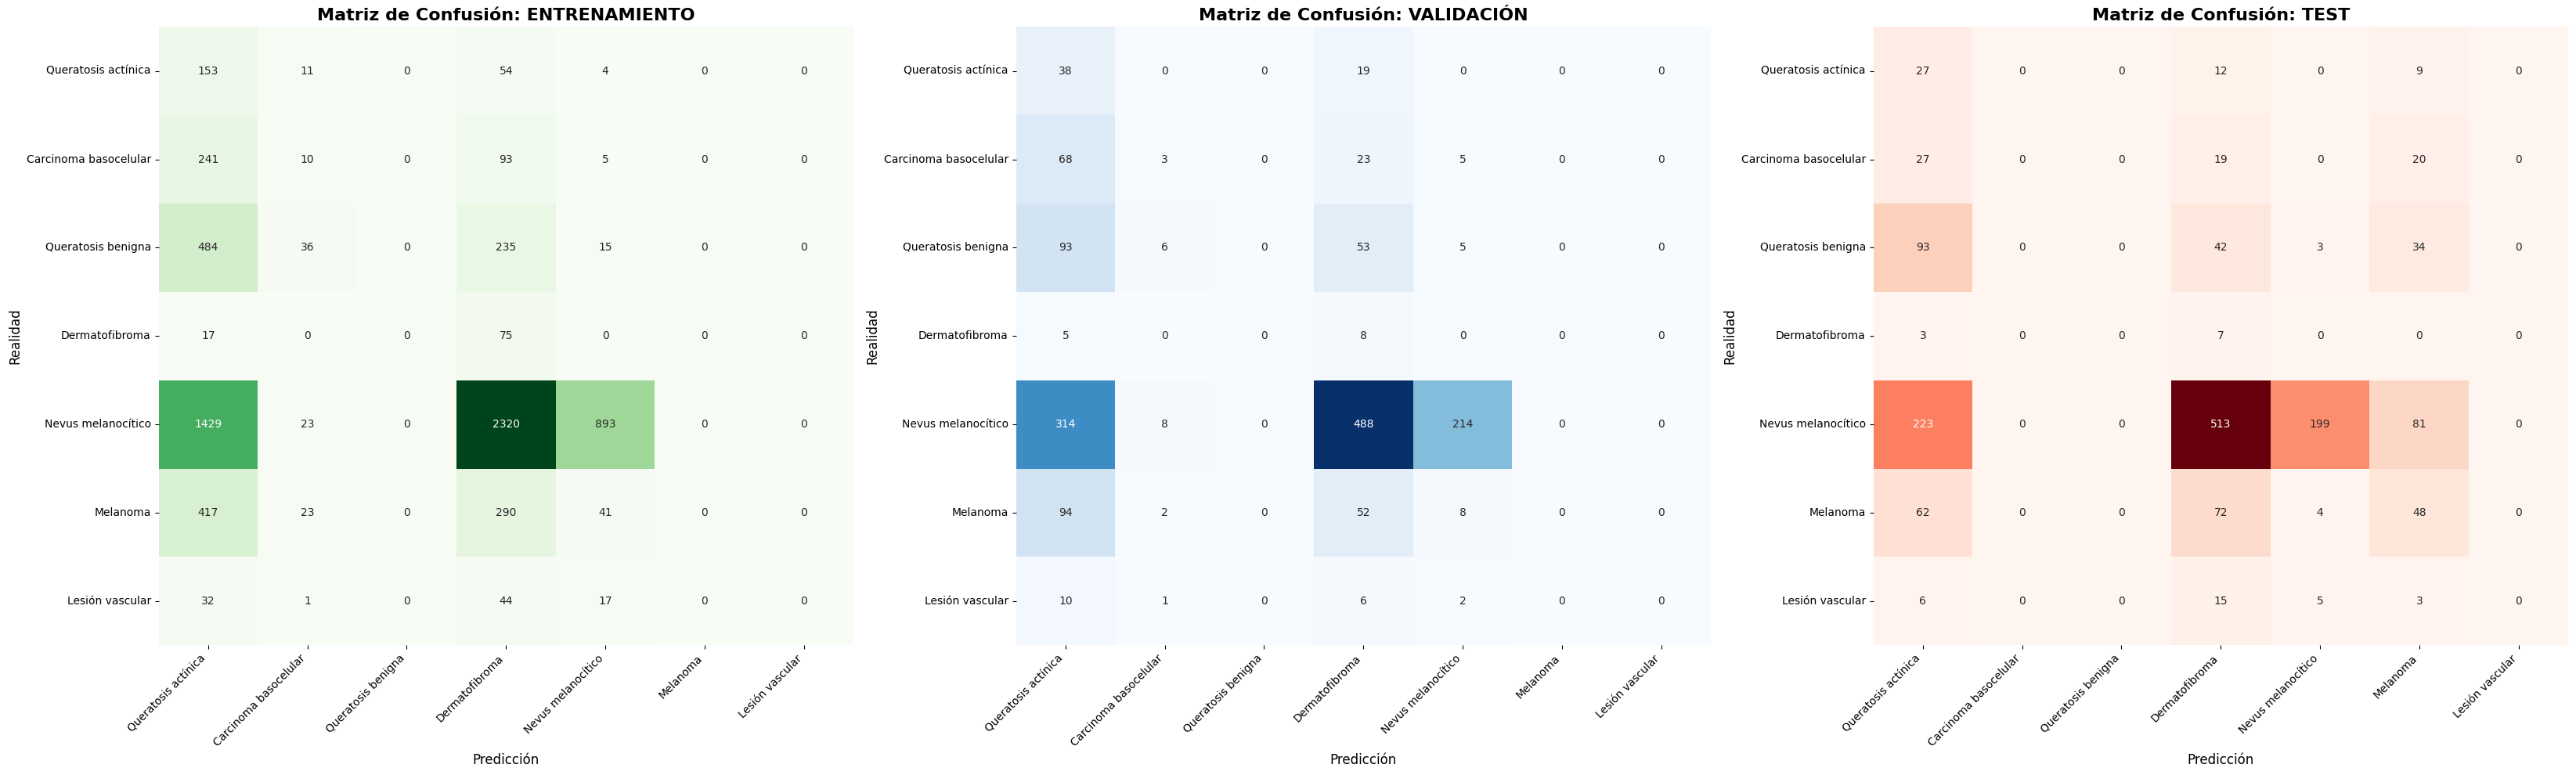

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_test = confusion_matrix(y_true_test, y_pred_test)
# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 3, figsize=(33, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# Matriz de Test (Roja)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax[2],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[2].set_title('Matriz de Confusión: TEST', fontsize=16, fontweight='bold')
ax[2].set_xlabel('Predicción', fontsize=12)
ax[2].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


Argmax
  Sensitivity (Recall MEL): 0.0000
  Specificity:             1.0000
  Precision:               0.0000
  F1-score:                0.0000

Custom Threshold (0.1)
  Sensitivity (Recall MEL): 0.2581
  Specificity:             0.8904
  Precision:               0.2462
  F1-score:                0.2520

Threshold 0.07
  Sensitivity (Recall MEL): 0.8656
  Specificity:             0.2886
  Precision:               0.1444
  F1-score:                0.2475

Sugerencia (Mayor Sensibilidad - Sens target: 0.85)
  Threshold Óptimo:         0.0708
  Sensitivity (Recall MEL): 0.8495
  Specificity:             0.3274
  Precision:               0.1491
  F1-score:                0.2536


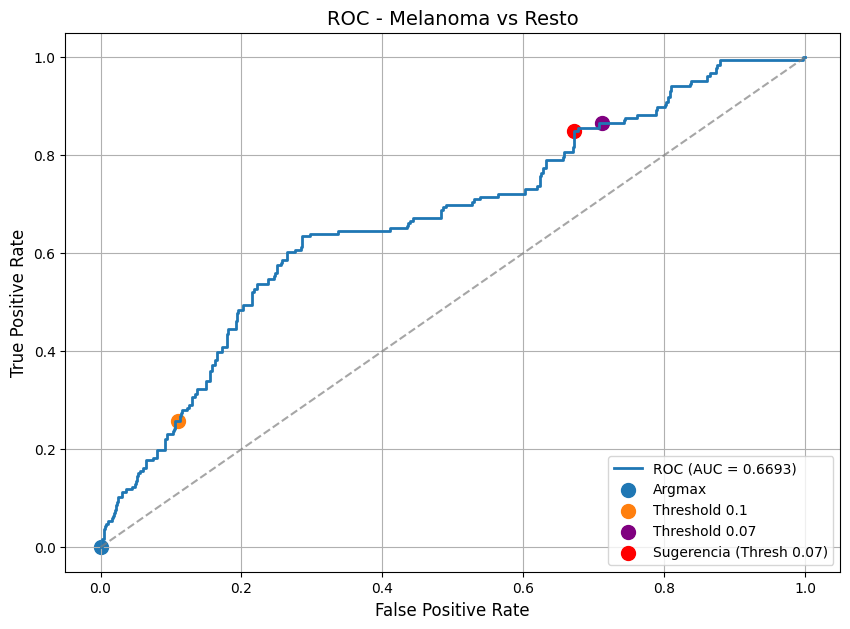

In [26]:
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, precision_score

# Asumimos que las funciones get_predictions_probs, apply_custom_threshold, apply_multi_threshold
# y test_ds ya están definidas y disponibles en tu entorno.

# =========================
# CONFIG (coherente con tu código)
# =========================
TARGET_IDX = 5  # Melanoma
THRESHOLD_CUSTOM = 0.1
THRESHOLD_01 = 0.07 # Nuevo threshold solicitado

# Multi-threshold (usa lo que ya estés probando)
THRESHOLD_MEL = 0.25
THRESHOLD_BCC = None
THRESHOLD_AK = None

# =========================
# OBTENER PROBABILIDADES (TU FUNCIÓN)
# =========================
# Asumiendo que esta línea ya está ejecutada y tienes y_true, y_probs
# y_true, y_probs = get_predictions_probs(test_ds, name="test")

# Binario: melanoma vs resto
y_true_bin = (y_true_test == TARGET_IDX).astype(int)
y_scores = y_probs_test[:, TARGET_IDX]

# =========================
# ROC
# =========================
# Capturamos también los thresholds para buscar el punto óptimo
fpr, tpr, thresholds = roc_curve(y_true_bin, y_scores) 
roc_auc = auc(fpr, tpr)

# =========================
# FUNCIÓN MÉTRICAS (simple y clara)
# =========================
def compute_metrics(y_true_bin, y_pred_bin, name=""):
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    
    print(f"\n{name}")
    print(f"  Sensitivity (Recall MEL): {sensitivity:.4f}")
    print(f"  Specificity:             {specificity:.4f}")
    print(f"  Precision:               {precision:.4f}")
    print(f"  F1-score:                {f1:.4f}")
    
    return tp, fp, fn, tn

def get_roc_point(tp, fp, fn, tn):
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return fpr, tpr

# Función auxiliar para encontrar métricas y threshold óptimo para una Sensibilidad dada
def find_optimal_threshold_metrics(target_sensitivity, y_true_bin, y_scores, name_prefix=""):
    fpr, tpr, thresholds = roc_curve(y_true_bin, y_scores)
    idx = (np.abs(tpr - target_sensitivity)).argmin() # Encuentra índice con TPR más cercano al objetivo
    optimal_threshold = thresholds[idx]
    
    # Calcular métricas usando este threshold específico
    y_pred_opt = (y_scores >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_opt).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_true_bin, y_pred_opt, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_opt, zero_division=0)
    
    print(f"\n{name_prefix} (Mayor Sensibilidad - Sens target: {target_sensitivity:.2f})")
    print(f"  Threshold Óptimo:         {optimal_threshold:.4f}")
    print(f"  Sensitivity (Recall MEL): {sensitivity:.4f}")
    print(f"  Specificity:             {specificity:.4f}")
    print(f"  Precision:               {precision:.4f}")
    print(f"  F1-score:                {f1:.4f}")
    
    return tp, fp, fn, tn, optimal_threshold

# =========================
# 1. ARGMAX (baseline real)
# =========================
y_pred_argmax = np.argmax(y_probs_test, axis=1)
y_pred_argmax_bin = (y_pred_argmax == TARGET_IDX).astype(int)

tp, fp, fn, tn = compute_metrics(y_true_bin, y_pred_argmax_bin, "Argmax")
fpr_arg, tpr_arg = get_roc_point(tp, fp, fn, tn)

# =========================
# 2. CUSTOM THRESHOLD
# =========================
y_pred_custom = apply_custom_threshold(y_probs_test, target_idx=TARGET_IDX, threshold=THRESHOLD_CUSTOM)
y_pred_custom_bin = (y_pred_custom == TARGET_IDX).astype(int)

tp, fp, fn, tn = compute_metrics(y_true_bin, y_pred_custom_bin, f"Custom Threshold ({THRESHOLD_CUSTOM})")
fpr_custom, tpr_custom = get_roc_point(tp, fp, fn, tn)

# =========================
# 3. THRESHOLD 0.1
# =========================
# Aplicamos el threshold binario directamente a las puntuaciones de melanoma
y_pred_01_bin = (y_scores >= THRESHOLD_01).astype(int)

tp, fp, fn, tn = compute_metrics(y_true_bin, y_pred_01_bin, f"Threshold {THRESHOLD_01}")
fpr_01, tpr_01 = get_roc_point(tp, fp, fn, tn)

# =========================
# 4. PUNTO Recall 0.85
# =========================
# Buscaremos el punto que obtenga una sensibilidad cercana al 85% y calcularemos sus métricas.
tp, fp, fn, tn, opt_thresh_high_sens = find_optimal_threshold_metrics(0.85, y_true_bin, y_scores, "Sugerencia")
fpr_high_sens, tpr_high_sens = get_roc_point(tp, fp, fn, tn)



# =========================
# PLOT (Modificado)
# =========================
plt.figure(figsize=(10,7)) 

plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})", linewidth=2)

plt.scatter(fpr_arg, tpr_arg, s=100, label="Argmax", marker='o')
plt.scatter(fpr_custom, tpr_custom, s=100, label=f"Threshold {THRESHOLD_CUSTOM}", marker='o')
plt.scatter(fpr_01, tpr_01, s=100, label=f"Threshold {THRESHOLD_01}", marker='o', color='purple')
plt.scatter(fpr_high_sens, tpr_high_sens, s=100, label=f"Sugerencia (Thresh {opt_thresh_high_sens:.2f})", marker='o', color='red')
plt.plot([0,1], [0,1], linestyle="--", color='grey', alpha=0.7)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC - Melanoma vs Resto", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)

plt.show()

/tmp/ipykernel_860040/377221753.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


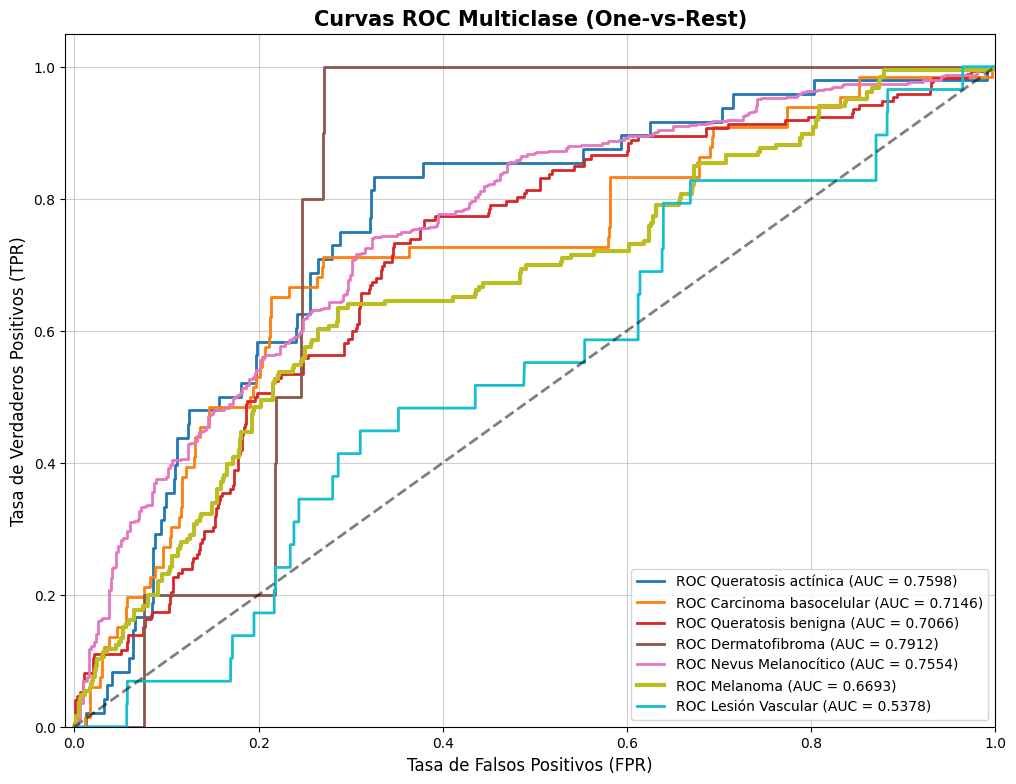

In [27]:
from sklearn.preprocessing import label_binarize

n_classes = y_probs_test.shape[1]

class_names = {
    0: "Queratosis actínica", 
    1: "Carcinoma basocelular",
    2: "Queratosis benigna",
    3: "Dermatofibroma",
    4: "Nevus Melanocítico",
    5: "Melanoma",
    6: "Lesión Vascular"
}

# =========================
# PREPARACIÓN DE DATOS
# =========================
# Binarizamos y_true para la estrategia One-vs-Rest. 
# Si y_true es [0, 5, 2], pasa a ser una matriz con 1s en la posición de la clase correcta.
classes_range = range(n_classes)
y_true_binarized = label_binarize(y_true_test, classes=classes_range)

# =========================
# PLOT MULTICLASE
# =========================
plt.figure(figsize=(12, 9))

# Usamos un mapa de colores (colormap) para asegurar que cada clase tenga un color distinto
colors = plt.cm.get_cmap('tab10', n_classes)

# Iteramos sobre cada clase para calcular y pintar su ROC-AUC
for i in range(n_classes):
    # Calculamos FPR y TPR comparando la clase 'i' contra todas las demás
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Obtenemos el nombre de la clase (o usamos "Clase i" por defecto)
    name = class_names.get(i, f"Clase {i}")
    
    # Destacamos el Melanoma con una línea un poco más gruesa
    linewidth = 3 if i == 5 else 2
    
    plt.plot(fpr, tpr, color=colors(i), lw=linewidth,
             label=f'ROC {name} (AUC = {roc_auc:.4f})')

# Línea de azar (random guess)
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)

# Formateo visual
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC Multiclase (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.6)

plt.show()

### Curvas de entrenamiento, validación y test

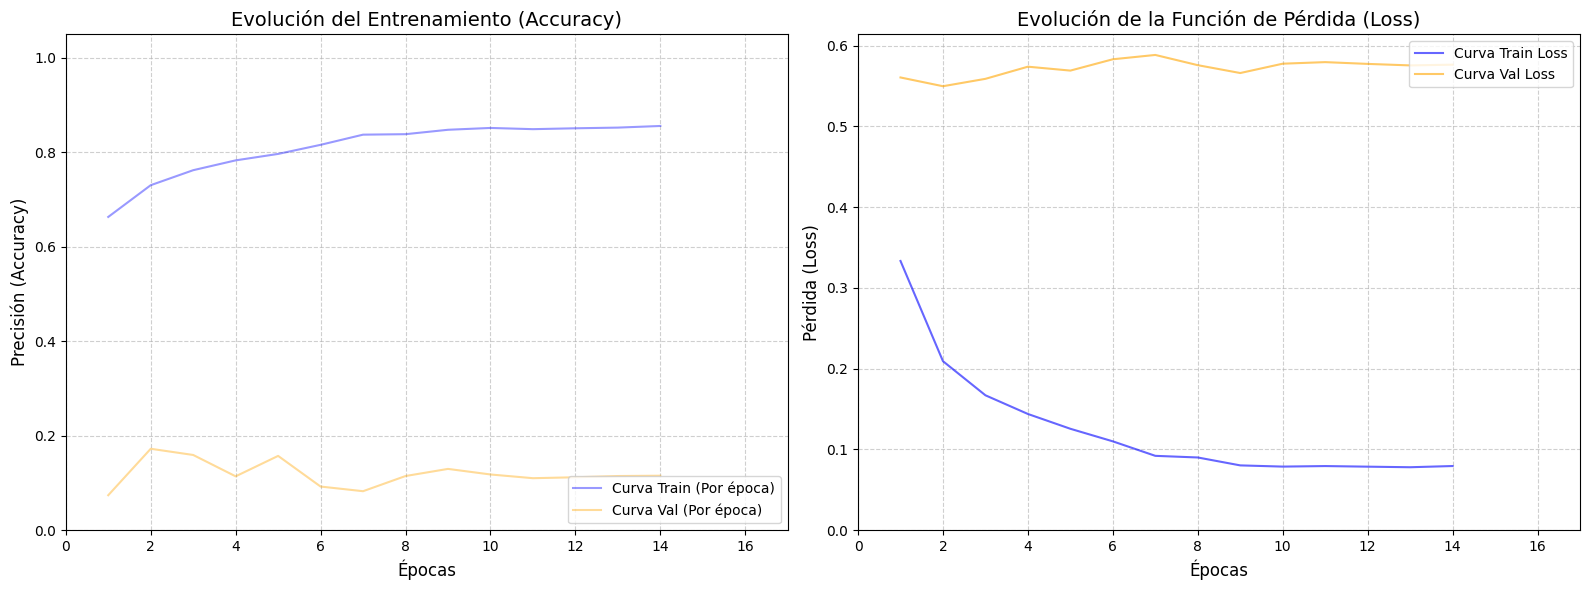

In [28]:
import matplotlib.pyplot as plt

if history:
    # Crear un lienzo con 1 fila y 2 columnas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    epochs_range = range(1, len(history.history["accuracy"]) + 1)
    final_epoch = len(history.history["accuracy"])

    # ==========================================
    # 1. GRÁFICA DE ACCURACY (Precisión)
    # ==========================================
    ax1.plot(
        epochs_range,
        history.history["accuracy"],
        label="Curva Train (Por época)",
        color="blue",
        alpha=0.4,
    )
    ax1.plot(
        epochs_range,
        history.history["val_accuracy"],
        label="Curva Val (Por época)",
        color="orange",
        alpha=0.4,
    )

    # Estética de la gráfica de Accuracy
    ax1.set_title("Evolución del Entrenamiento (Accuracy)", fontsize=14)
    ax1.set_xlabel("Épocas", fontsize=12)
    ax1.set_ylabel("Precisión (Accuracy)", fontsize=12)
    ax1.set_xlim(0, final_epoch + 3)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(loc="lower right", fontsize=10)


    # ==========================================
    # 2. GRÁFICA DE LOSS (Función de Pérdida)
    # ==========================================
    ax2.plot(
        epochs_range,
        history.history["loss"],
        label="Curva Train Loss",
        color="blue",
        alpha=0.6,
    )
    ax2.plot(
        epochs_range,
        history.history["val_loss"],
        label="Curva Val Loss",
        color="orange",
        alpha=0.6,
    )

    # Estética de la gráfica de Loss
    ax2.set_title("Evolución de la Función de Pérdida (Loss)", fontsize=14)
    ax2.set_xlabel("Épocas", fontsize=12)
    ax2.set_ylabel("Pérdida (Loss)", fontsize=12)
    ax2.set_xlim(0, final_epoch + 3)
    ax2.set_ylim(bottom=0) # El límite inferior es 0, el superior se ajusta automáticamente
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(loc="upper right", fontsize=10)

    # Ajustar el espaciado para que no se solapen
    plt.tight_layout()
    plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.

In [29]:

from skimage.segmentation import mark_boundaries, quickshift
from lime import lime_image
from matplotlib.colors import LinearSegmentedColormap
import contextlib
import shap
import matplotlib.cm as cm

# ==========================================
# 1. FUNCIONES CORE XAI
# ==========================================


def get_gradcam_heatmap(img_input, meta_input, model, last_conv_layer_name, pred_index):
    # v_model = model.get_layer('coatnet0')
    v_model = model.get_layer('efficientnetb0')
    inner_model = tf.keras.Model(
        inputs=v_model.inputs, 
        outputs=[v_model.get_layer(last_conv_layer_name).output, v_model.output]
    )
    pool_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)][0]
    concat_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Concatenate)][0]
    meta_branch = tf.keras.Model(inputs=model.input[1], outputs=concat_layer.input[1])
    
    top_input = tf.keras.Input(shape=concat_layer.output.shape[1:])
    x = top_input
    idx = model.layers.index(concat_layer)
    for layer in model.layers[idx+1:]:
        x = layer(x)
    top_model = tf.keras.Model(inputs=top_input, outputs=x)

    with tf.GradientTape() as tape:
        conv_output, backbone_out = inner_model(img_input)
        x_img = pool_layer(backbone_out)
        x_meta = meta_branch(meta_input)
        combined_features = concat_layer([x_img, x_meta])
        predictions = top_model(combined_features)
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# ==========================================
# 2. FUNCIÓN DE BÚSQUEDA INTELIGENTE (MULTIPLE)
# ==========================================

def buscar_n_ejemplos(class_idx, test_df, mode='correct', num_ejemplos=5):
    """ Busca en el set de test hasta N imágenes que el modelo haya acertado o fallado """
    df_filtrado = test_df[test_df['label'] == class_idx].sample(frac=1, random_state=42)
    
    ejemplos_encontrados = []
    
    for _, row in df_filtrado.iterrows():
        # Si ya encontramos los necesarios, salimos del bucle
        if len(ejemplos_encontrados) == num_ejemplos:
            break
            
        img_path = row['path']
        current_meta = np.array([row['meta']], dtype=np.float32)
        
        # Preparar imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0
        
        # Predecir
        pred = final_model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(pred[0])
        
        # Comprobar condición y almacenar
        if mode == 'correct' and pred_idx == class_idx:
            ejemplos_encontrados.append((img_path, img_input, img_raw, current_meta, pred_idx))
        elif mode == 'incorrect' and pred_idx != class_idx:
            ejemplos_encontrados.append((img_path, img_input, img_raw, current_meta, pred_idx))
            
    return ejemplos_encontrados

# ==========================================
# 3. GENERACIÓN DE TABLAS
# ==========================================

# sub_model = final_model.get_layer('coatnet0')
# last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]

sub_model = final_model.get_layer('backbone')
# La última capa convolucional de EfficientNetB0 suele ser 'top_conv'
last_conv_name = [l.name for l in sub_model.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]

explainer_lime = lime_image.LimeImageExplainer()
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

modos = ['correct', 'incorrect']
titulos_tabla = ["Aciertos del Modelo", "Fallos del Modelo (Errores de Predicción)"]

EJEMPLOS_POR_CLASE = 5 # <--- Ajusta aquí cuántos ejemplos quieres por clase

for mode, titulo in zip(modos, titulos_tabla):
    print(f"\n🚀 Recopilando ejemplos para: {titulo}...")
    
    # 1. Recopilar todos los ejemplos primero para saber cuántas filas dibujar
    lista_ejemplos_a_dibujar = []
    for i, nombre_clase in enumerate(class_names):
        resultados = buscar_n_ejemplos(i, test_df, mode=mode, num_ejemplos=EJEMPLOS_POR_CLASE)
        for res in resultados:
            lista_ejemplos_a_dibujar.append({'class_idx': i, 'data': res})
            
    n_filas = len(lista_ejemplos_a_dibujar)
    
    if n_filas == 0:
        print(f"⚠️ No se encontraron ejemplos para el modo '{mode}'.")
        continue

    print(f"✅ Se encontraron {n_filas} ejemplos en total. Generando tabla...")
    
    # 2. Crear la figura dinámica
    fig, axes = plt.subplots(nrows=n_filas, ncols=4, figsize=(22, 5 * n_filas))
    fig.suptitle(titulo, fontsize=24, fontweight='bold', y=1.02)
    
    # Si solo hay 1 fila, matplotlib devuelve axes como vector 1D. Lo forzamos a 2D para no romper el código.
    if n_filas == 1:
        axes = np.expand_dims(axes, axis=0)
    
    # Silenciamos la verbosidad de SHAP y LIME
    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        
        for row_idx, item in enumerate(lista_ejemplos_a_dibujar):
            clase_real_idx = item['class_idx']
            img_path, img_input, img_raw, current_meta, pred_idx = item['data']

            # C. WRAPPER PARA LIME/SHAP
            def hybrid_predict(batch):
                m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
                return final_model.predict([batch, m_batch], verbose=0)

            # 1. Grad-CAM
            h_map = get_gradcam_heatmap(img_input, current_meta, final_model, last_conv_name, pred_idx)
            gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
            mappable1 = cm.ScalarMappable(cmap="jet")
            mappable1.set_array([np.min(h_map), np.max(h_map)])
            cbar1 = plt.colorbar(mappable1, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)
            cbar1.ax.tick_params(labelsize=8)
            if row_idx == 0: cbar1.set_label('Importancia', fontsize=9)
            
            # 2. LIME
            exp = explainer_lime.explain_instance(
                img_input[0].astype('double'), 
                hybrid_predict, 
                top_labels=1, 
                num_samples=500,
                segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
            )
            temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
            
            # 3. SHAP
            masker = shap.maskers.Image("blur(8,8)", shape=(224, 224, 3))
            expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
            sv = expl_shap(img_input, max_evals=4000, batch_size=124) 
            shap_map = sv.values[0, :, :, :, pred_idx].sum(axis=-1)
            shap_cmap = LinearSegmentedColormap.from_list("shap", ["#1E88E5", "#ffffff", "#FF0D57"])
            orig = img_input[0].copy()  # ya normalizado a [0,1] por buscar_ejemplo
            vmax = np.nanpercentile(np.abs(sv.values), 99.9)
            norm = plt.Normalize(vmin=-vmax, vmax=vmax)
            alpha = 0.5  # Ajusta la transparencia de la superposición
            shap_rgba = shap_cmap(norm(shap_map))[:, :, :3] # colores puros del mapa
            blended = np.clip((1 - alpha) * orig + alpha * shap_rgba, 0, 1)  # mezcla manual
            im3 = axes[row_idx, 3].imshow(blended)
            axes[row_idx, 3].axis("off")
            sm = plt.cm.ScalarMappable(cmap=shap_cmap, norm=norm)  # colorbar referenciado a la norma
            sm.set_array([])
            cbar3 = plt.colorbar(sm, ax=axes[row_idx, 3], fraction=0.046, pad=0.04)
            cbar3.ax.tick_params(labelsize=8)
            if row_idx == 0: cbar3.set_label('| Contribucion +', fontsize=9)

            # --- RENDERIZADO ---
            axes[row_idx, 0].imshow(img_raw)
            
            # Etiquetas
            if mode == 'correct':
                etiqueta = class_names_es[clase_real_idx]
            else:
                etiqueta = f"Real: {class_names_es[clase_real_idx]}\nPredijo: {class_names_es[pred_idx]}"


            axes[row_idx, 0].set_ylabel(etiqueta, fontsize=12, fontweight='bold', color='red' if mode=='incorrect' else 'black')
            axes[row_idx, 1].imshow(gcam_res)
            axes[row_idx, 2].imshow(mark_boundaries(temp, mask))

            # Limpiar ejes
            for j in range(4):
                axes[row_idx, j].set_xticks([])
                axes[row_idx, j].set_yticks([])
                # Poner títulos solo en la primera fila global
                if row_idx == 0: 
                    axes[row_idx, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()

ValueError: No such layer: backbone. Existing layers are: ['image_input', 'rescaling', 'normalization', 'tf.math.multiply', 'stem_conv_pad', 'stem_conv', 'stem_bn', 'stem_activation', 'block1a_dwconv', 'block1a_bn', 'block1a_activation', 'block1a_se_squeeze', 'block1a_se_reshape', 'block1a_se_reduce', 'block1a_se_expand', 'block1a_se_excite', 'block1a_project_conv', 'block1a_project_bn', 'block2a_expand_conv', 'block2a_expand_bn', 'block2a_expand_activation', 'block2a_dwconv_pad', 'block2a_dwconv', 'block2a_bn', 'block2a_activation', 'block2a_se_squeeze', 'block2a_se_reshape', 'block2a_se_reduce', 'block2a_se_expand', 'block2a_se_excite', 'block2a_project_conv', 'block2a_project_bn', 'block2b_expand_conv', 'block2b_expand_bn', 'block2b_expand_activation', 'block2b_dwconv', 'block2b_bn', 'block2b_activation', 'block2b_se_squeeze', 'block2b_se_reshape', 'block2b_se_reduce', 'block2b_se_expand', 'block2b_se_excite', 'block2b_project_conv', 'block2b_project_bn', 'block2b_drop', 'block2b_ad